# Práctica 04: Análisis de datos Exploratorio con Python y Jupiter Notebook en un DataSet de Productoss de Amazon Store

**Progrma de estudios:** Ingeniería en Entornos Virtuales y Negocios Digitales \
**Asignatura:** Analítica de Base de Datos para Negocios Digitales \
**Docente:** M.T.I Marco Ramírez Hernández \
**Periodo:** Mayo - Agosto 2026

### Unidad 2: Preparación de los Datos

**Nombre del Estudiante:** Andrea Peña Leal \
**Matrícula:** 230379 \
**Grado y Grupo:** 9°A IEVND

<div style="background: linear-gradient(135deg, #FF9900 0%, #232F3E 100%); padding: 30px; border-radius: 15px; text-align: center; margin-bottom: 20px;">
<h1 style="color: white; font-size: 2.2em; margin: 0;"> 
    🛒Productos de Amazon Store - Análisis Exploratorio de Datos Completo & Aprendizaje Automático Predictivo 
    (ML)
</h1>
<p style="color: #FFD700; font-size: 1.1em; margin-top: 10px;">
    Predicción de Precisos - Análisis de Categorias - Ingenieria de Funcionalidades - Comparación de Modeles
</p>
</div>

## Tabla de contenido 
| # | Sección | Descripción |
|---|---|---|
| 1 | [Instalaciones & Carga de datos](#s1) | Librerías, carga de CSV, primeros comandos de estructura.|
| 2 | [Diccionario de Datos](#s2) | Explicación del contenido de columnas y calcular el % de datos faltantes.|
| 3 | [Limpieza de Datos](#s3) | Aplicación de métodos básicos de limpieza (eliminación duplicados, agrupación, datos nulos.|
| 4 | [Ingenieria de Caracteristicas (Feature Engineering) ](#s4) | Crear, transformar, seleccionar o mejorar variables (features) de un conjunto de datos.|
| 5 | [Análisis Univariado (Univariate Analysis)](#s5) |  Distribuciones, valores atípicos, pruebas de normalidad.|
| 6 | [Análisis de Categorías (Category Analysis)](#s6) |Categorías principales, precio por categoría.|
| 7 | [Análisis de Disponibilidad (Availability Analysis)](#s7) |Patrones de estado de inventario.|
| 8 | [Análisis de Correlación y Análisis Bivariado (Correlation & Bivariate Analysis)](#s8) | Mapa de calor, gráficos de dispersión.|
| 9 | [Prueba de hipótesis estadística](#s9) |ANOVA, Kruskal-Wallis, Spearman |
| 10 | [Definición del Problema de Machine Learning](#s10) |Matriz de características, train/test spli.|
| 11 | [Marco de selección de modelos ](#s11) |Tabla comparativa de modelos, métricas.|
| 12 | [Modelos de regresión](#s12) | 5 modelos entrenados y evaluados. |
| 13 | [Ajuste de hiperparámetros](#s12) | GridSearchCV sobre el mejor modelo. |
| 14 | [Comparación de modelos](#s14) | Resultados lado a lado, importancia de variables. |
| 14 | [Conclusiones y reporte](#s14) | Hallazgos de negocio, recomendaciones |

## 1. Instalaciones & Carga de Datos  🔧<a id='s1'></a>
<div style="background:#f0f8ff; padding:12px; border-left:4px solid #FF9900; border-radius:5px; color:#0066cc;">
<b>Dataset:</b> Amazon India Listas de Productos - 1,436 productos entre Libros, Kindle, Deportes & más<br>
<b>Objetivo:</b> Predecir el precio del producto (INR) desde la categoría, longitud del nombre, y disponibilidad<br>
<b>DataSource:</b> Web-scraped de páginas de productos Amazon.in
</div>

In [14]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
from scipy.stats import mannwhitneyu, kruskal, spearmanr
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler



#ml -Machine Learning -Entretenimiento de modelos metricas para predicir en este caso precios
from sklearn.preprocessing import LabelEncoder, StandardScaler  

print(f'Pandas   : {pd.__version__}')
print(f'NumPy    : {np.__version__}')
print('¡Todas las librerías cargaron con éxito!')

Pandas   : 2.3.3
NumPy    : 2.3.5
¡Todas las librerías cargaron con éxito!


In [19]:
df_raw = pd.read_csv('./amazon_products_data.csv', encoding='latin-1')
print(f' Shape   : {df_raw.shape}')
print(f' Columns   : {df_raw.columns.tolist()}')
df_raw.head(3)

 Shape   : (1449, 17)
 Columns   : ['rl', 'asin', 'name', 'overview', 'price', 'currency', 'availability', 'brand', 'about_item', 'img_source', 'description', 'specifications', 'primary_category', 'category_1', 'category_2', 'category_3', 'breadcrumbs']


,rl,asin,name,overview,price,currency,availability,brand,about_item,img_source,description,specifications,primary_category,category_1,category_2,category_3,breadcrumbs
0,https://www.amazon.in/dp/1788832566,1788832566,Hands-On Design Patterns with C++: Solve commo...,[],"1,600.00",INR,NaN,by \r\n Fedor G. Pikus (...,NaN,https://images-na.ssl-images-amazon.com/images...,NaN,[],Books,Computers & Internet,Programming & Software Development,NaN,Books | Computers & Internet | Programming & S...
1,https://www.amazon.in/dp/0766199592,0766199592,The Blazing Horizon The True Story of Pawnee B...,[],"2,399.00",INR,Usually dispatched in 13 to 14 days.,by \r\nErnest Lynn \r\n(Author),NaN,https://images-na.ssl-images-amazon.com/images...,NaN,[],Books,Action & Adventure,NaN,NaN,Books | Action & Adventure
2,https://www.amazon.in/dp/B071ZCD9XH,B071ZCD9XH,Fast and easy lunch box: A collection of 15eas...,[],NaN,NaN,NaN,by \r\nNinety Nine Cents Pr...,NaN,https://m.media-amazon.com/images/I/41g9Z21QuG...,NaN,[],Kindle Store,Kindle eBooks,"Crafts, Home & Lifestyle",NaN,"Kindle Store | Kindle eBooks | Crafts, Home & ..."


## 2. Diccionario de Datos <a id='s2'></a>

In [20]:
# Column dictionary
col_info = {
    'rl'             : 'URL del Producto en Amazon.in',
    'asin'            : 'Número Estandarizado de Identificación por Amazon (unique ID)',
    'name'            : 'Nombre o Título del Producto',
    'overview'        : 'Breve Reseña del Prodcuto (mayoría vacío [])',
    'price'           : 'Precio como string (e.g. "1,600.00")',
    'currency'        : 'Código de Divisa (todas en INR)',
    'availability'    : 'Texto del Status del Stock (Inventario)',
    'brand'           : 'Nombre de la Marca/Autor ',
    'about_item'      : 'Detalles/Especificaciones (mayoría faltante)',
    'img_source'      : 'URLs de Imágenes del Producto',
    'description'     : 'Descripción detalla y completa (mayoría faltante)',
    'specifications'  : 'Especificaciones Técnicas',
    'primary_category': 'Categoría Principal (Libros, Kindle, Deportes...)',
    'category_1'      : 'Subcategoría de nivel 1',
    'category_2'      : 'Subcategoría de nivel 2',
    'category_3'      : 'Subcategoría de nivel 3',
    'breadcrumbs'     : 'Ruta de Categorías',
}

print('Diccionario por columnas:')

for col, desc in col_info.items():
    missing_pct = df_raw[col].isnull().mean() * 100
    print(
        f'{col:20s}  | '
        f'{desc[:45]:45s} | '
        f' Missing: {missing_pct:.0f}%'
        )
    

Diccionario por columnas:
rl                    | URL del Producto en Amazon.in                 |  Missing: 0%
asin                  | Número Estandarizado de Identificación por Am |  Missing: 0%
name                  | Nombre o Título del Producto                  |  Missing: 0%
overview              | Breve Reseña del Prodcuto (mayoría vacío [])  |  Missing: 0%
price                 | Precio como string (e.g. "1,600.00")          |  Missing: 24%
currency              | Código de Divisa (todas en INR)               |  Missing: 24%
availability          | Texto del Status del Stock (Inventario)       |  Missing: 33%
brand                 | Nombre de la Marca/Autor                      |  Missing: 1%
about_item            | Detalles/Especificaciones (mayoría faltante)  |  Missing: 92%
img_source            | URLs de Imágenes del Producto                 |  Missing: 1%
description           | Descripción detalla y completa (mayoría falta |  Missing: 92%
specifications        | Especifica

## 3. Limpieza de Datos <a id='s3'></a>

<div style="background:#fff8e1; padding:12px; border-left:4px solid #FF9900; border-radius:5px; color: #0066cc;">
<b>Pasos clave para la limpieza:</b><br>
• Parseas el precio strings como "1,600.00" -> float 1600.0<br>
• Manejar los datos faltantes (price: 24%, availability: 33%, description: 92%)<br>
• Estandarizar el texto de disponibilidad en categorías limpias<br>
• Eliminar duplicados
</div>

In [21]:
# =====================================================================
# SECTION 3- Data Cleaning
# =====================================================================
df = df_raw.copy()

# ---------------------------------------------------------------------
# —- Parse price —-
# ---------------------------------------------------------------------
def clean_price(p):
    if pd.isna(p): return np.nan
    p = str(p).replace(',', '').strip()
    m = re.search(r'[\d.]+', p)
    return float(m.group()) if m else np.nan

df['price_clean'] = df['price'].apply(clean_price)


# ---------------------------------------------------------------------
# —- Standardise availability —-
# ---------------------------------------------------------------------
def clean_availability(a):
    if pd.isna(a): return 'Unknown'
    a = str(a).strip().lower()
    if 'in stock' in a:               return 'In Stock'
    if 'unavailable' in a:           return 'Unavailable'
    if '1 to 3' in a:                 return 'Ships 1-3 weeks'
    if '4 to 5' in a or '6 to' in a or '9 to' in a: return 'Ships 4-14 days'
    if '13 to 14' in a or '2 to 3 weeks' in a:      return 'Ships 2+ weeks'
    if 'only' in a and 'left' in a:   return 'Low Stock'
    if '2 to 3 days' in a or '1 to 2 days' in a:    return 'Ships 1-3 days'
    return 'Other'

df['avail_clean'] = df['availability'].apply(clean_availability)


# ---------------------------------------------------------------------
# —- Text length features —-
# ---------------------------------------------------------------------
df['name_length'] = df['name'].fillna('').str.len()
df['name_words']  = df['name'].fillna('').str.split().str.len()
df['has_brand']   = df['brand'].notna().astype(int)
df['has_desc']    = df['description'].notna().astype(int)
df['has_specs']   = df['specifications'].notna().astype(int)


# ---------------------------------------------------------------------
# —- Duplicate check —-
# ---------------------------------------------------------------------
dupes = df.duplicated(subset='asin').sum()

print(f'✅ Price parsed: {df["price_clean"].notna().sum():,} / {len(df):,} products')
print(f'✅ Duplicate ASINs: {dupes}')
print(f'✅ Availability categories: {df["avail_clean"].value_counts().to_dict()}')

# Mostrar las primeras 5 filas con columnas seleccionadas
df[['name', 'price_clean', 'avail_clean', 'primary_category', 'name_length']].head(5)

✅ Price parsed: 1,100 / 1,449 products
✅ Duplicate ASINs: 11
✅ Availability categories: {'In Stock': 609, 'Unknown': 482, 'Ships 1-3 weeks': 122, 'Ships 4-14 days': 115, 'Ships 2+ weeks': 80, 'Other': 25, 'Ships 1-3 days': 16}


,name,price_clean,avail_clean,primary_category,name_length
0,Hands-On Design Patterns with C++: Solve commo...,1600.0,Unknown,Books,118
1,The Blazing Horizon The True Story of Pawnee B...,2399.0,Ships 2+ weeks,Books,74
2,Fast and easy lunch box: A collection of 15eas...,NaN,Unknown,Kindle Store,108
3,European Foreign Policy Scorecard 2014,NaN,Unknown,Kindle Store,38
4,The 13th Hour: Chaos (Volume 2) (The Nick Quin...,1849.0,Ships 2+ weeks,Books,64


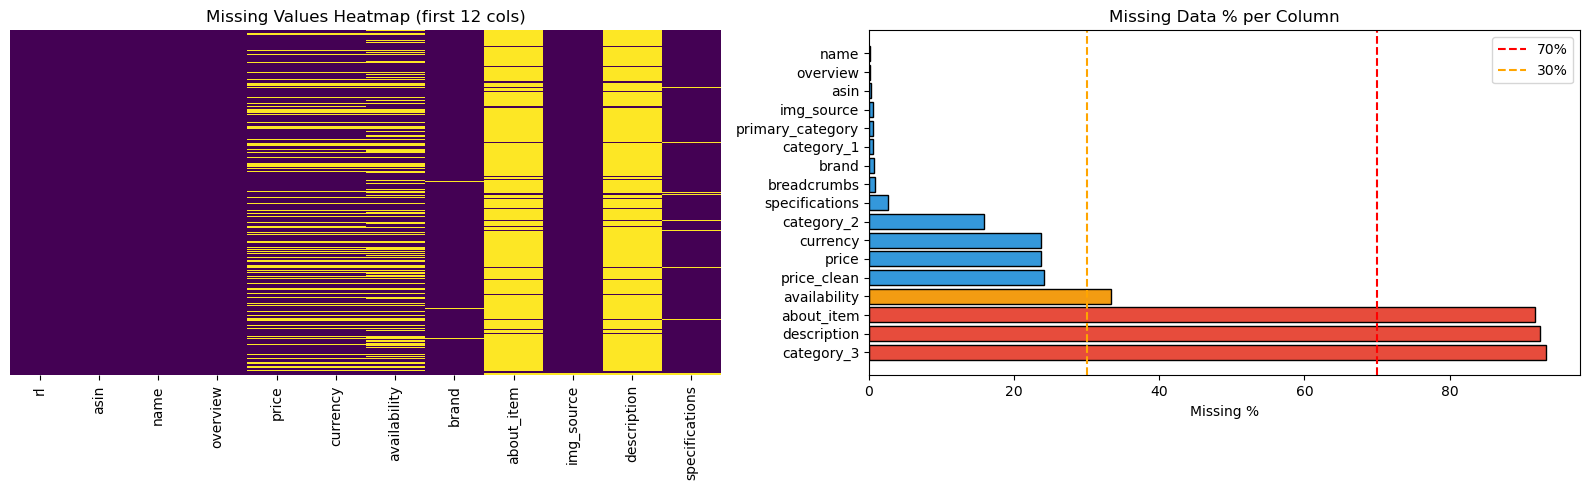

                  Missing Count  Missing Pct
category_3                 1352         93.3
description                1340         92.5
about_item                 1329         91.7
availability                482         33.3
price_clean                 349         24.1
price                       344         23.7
currency                    344         23.7
category_2                  230         15.9
specifications               38          2.6
breadcrumbs                  12          0.8
brand                        10          0.7
category_1                    9          0.6
primary_category              9          0.6
img_source                    9          0.6
asin                          4          0.3
overview                      3          0.2
name                          1          0.1


In [22]:
# Missing value summary
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing Pct'  : (df.isnull().sum() / len(df) * 100).round(1)
}).sort_values('Missing Pct', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.heatmap(df[df.columns[:12]].isnull(), cbar=False, yticklabels=False,
            cmap='viridis', ax=axes[0])
axes[0].set_title('Missing Values Heatmap (first 12 cols)')

mv = missing[missing['Missing Pct'] > 0]
colors_mv = ['#e74c3c' if v > 70 else '#f39c12' if v > 30 else '#3498db'
             for v in mv['Missing Pct']]
axes[1].barh(mv.index, mv['Missing Pct'], color=colors_mv, edgecolor='black')
axes[1].axvline(70, color='red', linestyle='--', label='70%')
axes[1].axvline(30, color='orange', linestyle='--', label='30%')
axes[1].set_xlabel('Missing %'); axes[1].set_title('Missing Data % per Column')
axes[1].legend()

plt.tight_layout(); plt.show()
print(missing[missing['Missing Count'] > 0].to_string())



## 4. Ingenieria de Caracteristicas (Feature Engineering) <a id='s3'></a>

<div style="background:#f0fff0; padding:12px; border-left:4px solid #27ae60; border-radius:5px; color:#0066cc;">
<b>Ejemplo Cotidiano:</b> Un agente inmobiliario no solo utiliza los metros cuadrados brutos, sino que también considera la ubicación, la antigüedad y
el estado. Nosotros hacemos lo mismo: extraemos información más valiosa del texto sin procesar y las categorías..
</div>

In [47]:
# ============================================================
# SECTION 4 — Feature Engineering
# ============================================================

# ── Category flags ───────────────────────────────────────────
df['is_book']    = (df['primary_category'] == 'Books').astype(int)
df['is_kindle']  = (df['primary_category'] == 'Kindle Store').astype(int)
df['is_sports']  = (df['primary_category'].str.contains('Sport', na=False)).astype(int)

# ── Sub-category flags ───────────────────────────────────────
df['is_fiction']    = df['category_1'].fillna('').str.contains('Fiction|Adventure|Crime|Romance|Sci-Fi', case=False).astype(int)
df['is_nonfiction'] = df['category_1'].fillna('').str.contains('History|Politics|Business|Science|Education', case=False).astype(int)
df['is_tech']       = df['category_1'].fillna('').str.contains('Computer|Programming|Technology', case=False).astype(int)
df['is_cycling']    = df['category_1'].fillna('').str.contains('Cycling', case=False).astype(int)

# ── Availability flags ───────────────────────────────────────
df['is_instock']     = (df['avail_clean'] == 'In Stock').astype(int)
df['is_unavailable'] = (df['avail_clean'] == 'Unavailable').astype(int)
df['is_lowstock']    = (df['avail_clean'] == 'Low Stock').astype(int)

# ── Price features ───────────────────────────────────────────
df['log_price'] = np.log1p(df['price_clean'])

def price_tier(p):
    if pd.isna(p):  return 'Unknown'
    if p < 300:     return '1_budget'
    if p < 800:     return '2_low'
    if p < 1500:    return '3_mid'
    if p < 3000:    return '4_premium'
    return '5_luxury'

df['price_tier'] = df['price_clean'].apply(price_tier)

# ── Label encode primary category ───────────────────────────
le_cat = LabelEncoder()
df['primary_cat_enc'] = le_cat.fit_transform(df['primary_category'].fillna('Unknown'))

le_cat1 = LabelEncoder()
df['cat1_enc'] = le_cat1.fit_transform(df['category_1'].fillna('Unknown'))

le_avail = LabelEncoder()
df['avail_enc'] = le_avail.fit_transform(df['avail_clean'])

print(f'✅ Total features engineered: {len(df.columns)}')
print('\nPrice tier distribution:')
print(df['price_tier'].value_counts().sort_index().to_string())
df[['name','price_clean','price_tier','primary_category','is_book','is_instock']].head(6)

✅ Total features engineered: 39

Price tier distribution:
price_tier
1_budget     104
2_low        288
3_mid        319
4_premium    262
5_luxury     127
Unknown      349


,name,price_clean,price_tier,primary_category,is_book,is_instock
0,Hands-On Design Patterns with C++: Solve commo...,1600.0,4_premium,Books,1,0
1,The Blazing Horizon The True Story of Pawnee B...,2399.0,4_premium,Books,1,0
2,Fast and easy lunch box: A collection of 15eas...,NaN,Unknown,Kindle Store,0,0
3,European Foreign Policy Scorecard 2014,NaN,Unknown,Kindle Store,0,0
4,The 13th Hour: Chaos (Volume 2) (The Nick Quin...,1849.0,4_premium,Books,1,0
5,Valerius Maximus' Memorable Deeds and Sayings ...,NaN,Unknown,Books,1,0


## 5. Análisis Univariado (Univariate Analysis) 📊 <a id='s5'></a>

<div style="background:#eaf4ff; padding:12px; border-left:4px solid #0066cc; border-radius:5px; color:#0066cc;">
<b>Pregunta clave:</b> ¿Cómo es la distribución de los precios? ¿Existen valores atípicos (outliers)? ¿Los datos presentan asimetría (sesgo)?.
</div>

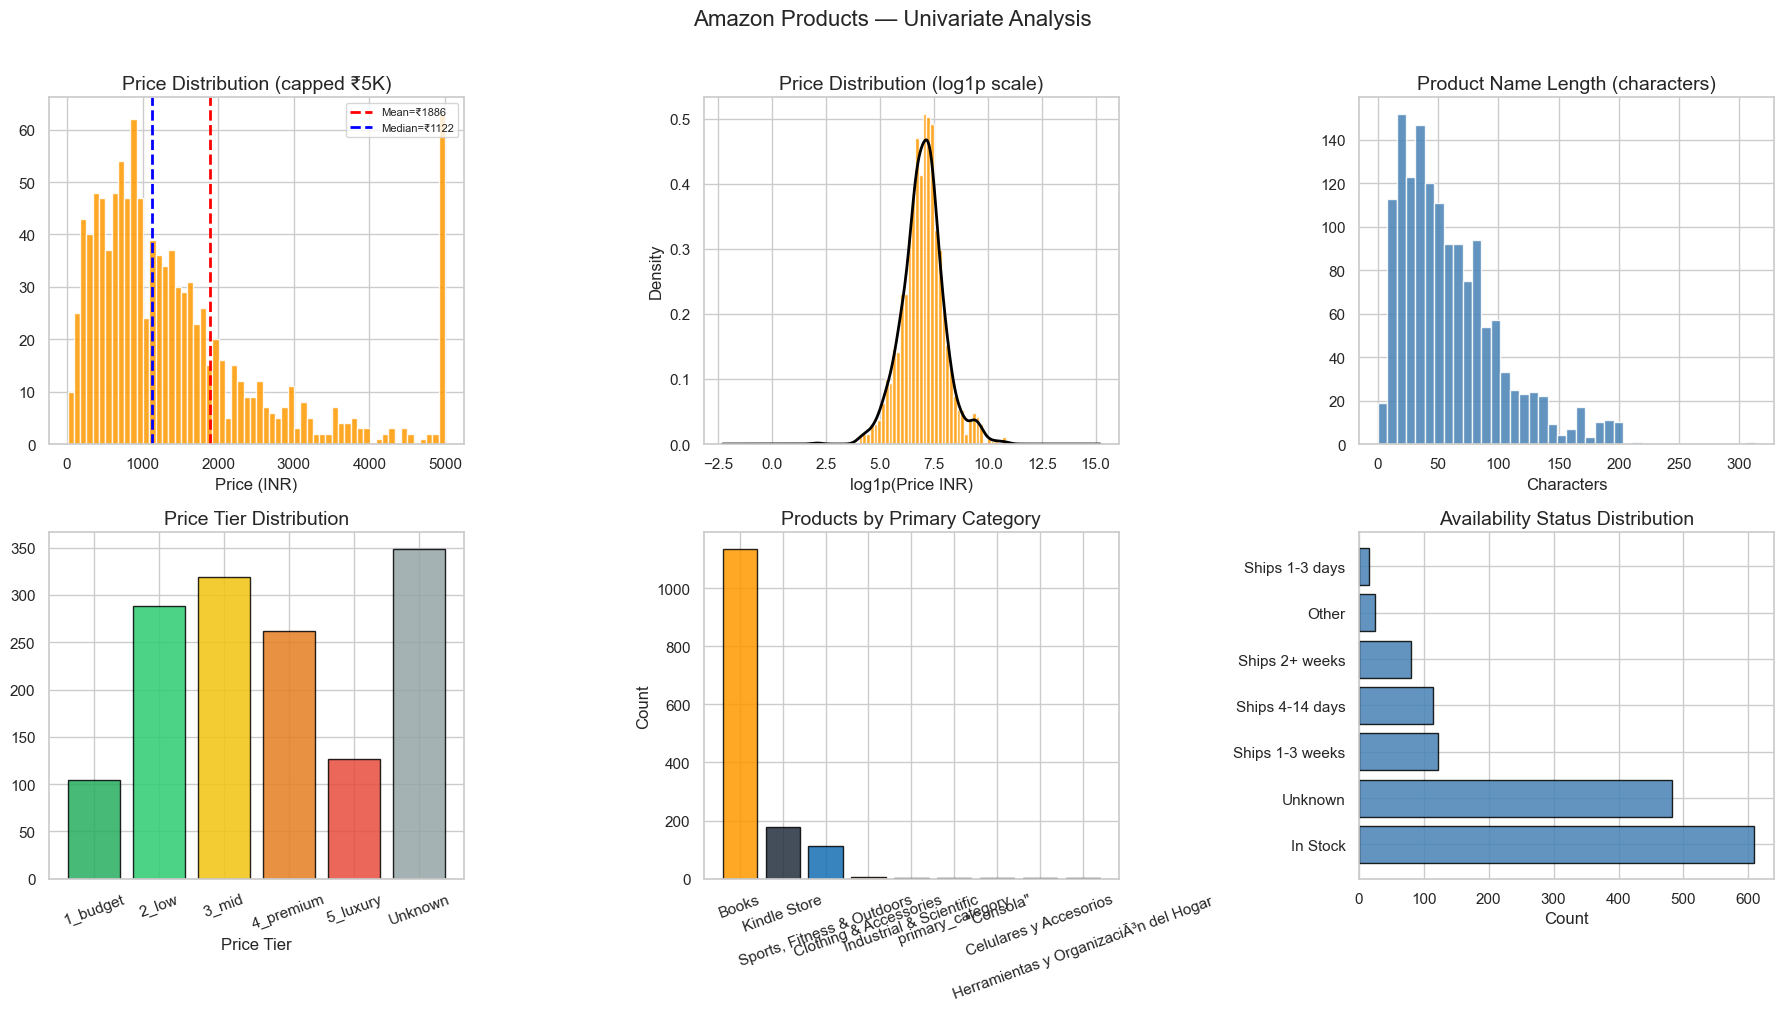

Shapiro-Wilk (log price, n=500): stat=0.9876, p=0.000296
Price is still non-normal after log transform

Price stats (INR):
count     1093.00
mean      1886.47
std       3343.82
min          7.00
25%        613.06
50%       1122.00
75%       1850.00
max      50555.00


In [46]:
# ============================================================
# 📊 Sección 5 — Análisis Univariado
# ============================================================

# Filtrar únicamente productos con precio válido y mayor a cero
df_priced = df[df['price_clean'].notna() & (df['price_clean'] > 0)].copy()

# Crear una figura con 2 filas y 3 columnas de gráficos
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# ============================================================
# Distribución de precios originales
# ============================================================

# Histograma de precios limitando valores máximos a ₹5000
# para evitar que los outliers distorsionen la visualización
axes[0,0].hist(
    df_priced['price_clean'].clip(upper=5000),
    bins=60,
    color='#FF9900',
    edgecolor='white',
    alpha=0.85
)

# Línea vertical para la media
axes[0,0].axvline(
    df_priced['price_clean'].mean(),
    color='red',
    linestyle='--',
    lw=2,
    label=f'Mean=₹{df_priced["price_clean"].mean():.0f}'
)

# Línea vertical para la mediana
axes[0,0].axvline(
    df_priced['price_clean'].median(),
    color='blue',
    linestyle='--',
    lw=2,
    label=f'Median=₹{df_priced["price_clean"].median():.0f}'
)

# Configuración del gráfico
axes[0,0].set_title('Price Distribution (capped ₹5K)')
axes[0,0].set_xlabel('Price (INR)')
axes[0,0].legend(fontsize=8)

# ============================================================
# Distribución de precios transformados con logaritmo
# ============================================================

# Histograma de precios transformados usando log1p
axes[0,1].hist(
    df_priced['log_price'],
    bins=50,
    color='#FF9900',
    edgecolor='white',
    alpha=0.85,
    density=True
)

# Curva de densidad (KDE)
df_priced['log_price'].plot.kde(
    ax=axes[0,1],
    color='black',
    lw=2
)

# Configuración del gráfico
axes[0,1].set_title('Price Distribution (log1p scale)')
axes[0,1].set_xlabel('log1p(Price INR)')

# ============================================================
# Longitud del nombre de los productos
# ============================================================

# Histograma de la cantidad de caracteres en los nombres
axes[0,2].hist(
    df['name_length'],
    bins=40,
    color='steelblue',
    edgecolor='white',
    alpha=0.85
)

# Configuración del gráfico
axes[0,2].set_title('Product Name Length (characters)')
axes[0,2].set_xlabel('Characters')

# ============================================================
# Distribución por rango de precios (Price Tier)
# ============================================================

# Contar productos por nivel de precio
tier_counts = df['price_tier'].value_counts().sort_index()

# Colores para cada nivel
tier_colors = ['#27ae60','#2ecc71','#f1c40f','#e67e22','#e74c3c','#95a5a6']

# Crear gráfico de barras
axes[1,0].bar(
    tier_counts.index,
    tier_counts.values,
    color=tier_colors[:len(tier_counts)],
    edgecolor='black',
    alpha=0.85
)

# Configuración del gráfico
axes[1,0].set_title('Price Tier Distribution')
axes[1,0].set_xlabel('Price Tier')
axes[1,0].tick_params(axis='x', rotation=20)

# ============================================================
# Productos por categoría principal
# ============================================================

# Contar productos por categoría
cat_counts = df['primary_category'].value_counts()

# Crear gráfico de barras
axes[1,1].bar(
    cat_counts.index,
    cat_counts.values,
    color=['#FF9900','#232F3E','#146EB4','#E47911','#999'],
    edgecolor='black',
    alpha=0.85
)

# Configuración del gráfico
axes[1,1].set_title('Products by Primary Category')
axes[1,1].set_ylabel('Count')
axes[1,1].tick_params(axis='x', rotation=20)

# ============================================================
# Distribución del estado de disponibilidad
# ============================================================

# Contar productos según su disponibilidad
avail_counts = df['avail_clean'].value_counts()

# Crear gráfico de barras horizontales
axes[1,2].barh(
    avail_counts.index,
    avail_counts.values,
    color='steelblue',
    edgecolor='black',
    alpha=0.85
)

# Configuración del gráfico
axes[1,2].set_title('Availability Status Distribution')
axes[1,2].set_xlabel('Count')

# ============================================================
# Mostrar todos los gráficos
# ============================================================

# Título general de la figura
plt.suptitle('Amazon Products — Univariate Analysis', fontsize=16, y=1.01)

# Ajustar espacios automáticamente
plt.tight_layout()

# Mostrar figura
plt.show()

# ============================================================
# Prueba de normalidad Shapiro-Wilk
# ============================================================

# Tomar una muestra de hasta 500 registros para evaluar normalidad
stat, p = shapiro(
    df_priced['log_price'].sample(
        min(500, len(df_priced)),
        random_state=42
    )
)

# Mostrar resultado de la prueba
print(f'Shapiro-Wilk (log price, n=500): stat={stat:.4f}, p={p:.6f}')

# Interpretación automática
print(
    f'Price is {"normally distributed after log transform" if p > 0.05 else "still non-normal after log transform"}'
)

# ============================================================
# Estadísticas descriptivas de los precios
# ============================================================

print(f'\nPrice stats (INR):')

# Mostrar resumen estadístico
print(
    df_priced['price_clean']
    .describe()
    .round(2)
    .to_string()
)

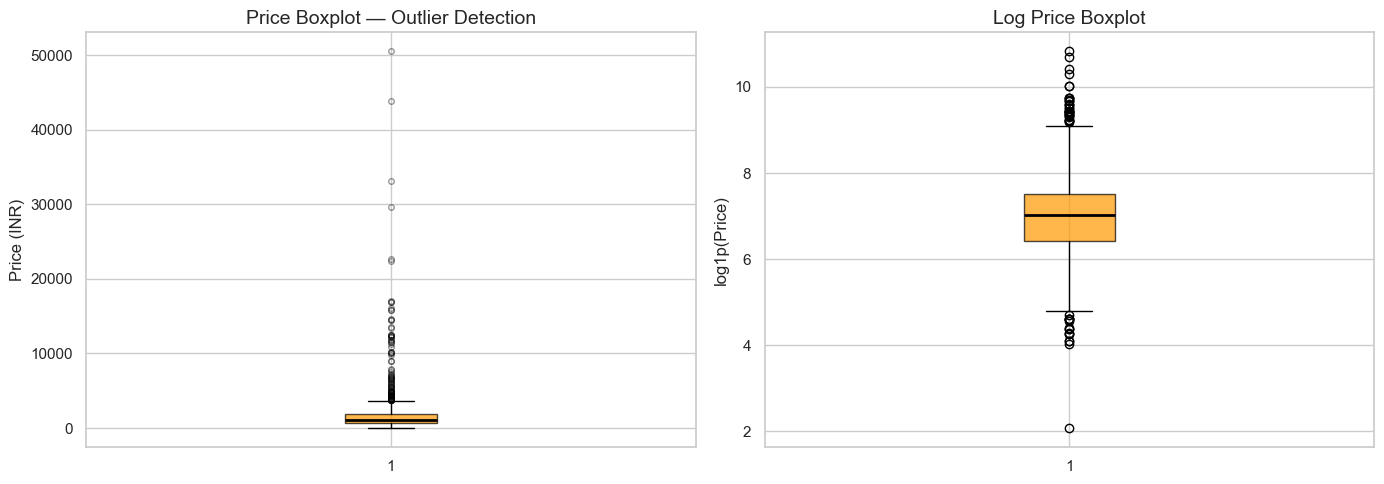

IQR method outliers: 94 (8.6%)
Price range (non-outlier): ₹-1242 – ₹3705

Top 10 most expensive products:
                                                                                                                                        name  price_clean           primary_category
                                            Sprache und Literatur (Literatur der julisch-claudischen und der flavischen Zeit [Schluss]): 032     50555.00                      Books
                                                         Data Mining Algorithms in C++: Data Patterns and Algorithms for Modern Applications     43936.00                      Books
                                                                                Birnbaum's Walt Disney World for Kids 2008 (Birnbaum Guides)     33180.00                      Books
                                                                            Professional Short Films with Autodesk 3ds Max (Graphics Series)     29633.00                 

In [45]:
# 📦 Análisis de Valores Atípicos (Outlier Analysis) usando Boxplot e IQR

# Crear una figura con 2 gráficos (1 fila y 2 columnas)
# figsize define el tamaño total de la figura
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ==========================
# Boxplot de precios originales
# ==========================

# Generar diagrama de caja para la columna 'price_clean'
axes[0].boxplot(
    df_priced['price_clean'],
    patch_artist=True,  # Permite colorear la caja
    boxprops=dict(facecolor='#FF9900', alpha=0.7),  # Color de la caja
    medianprops=dict(color='black', lw=2),          # Línea de la mediana
    flierprops=dict(marker='o', markersize=4, alpha=0.4, color='red')  # Valores atípicos
)

# Título del gráfico
axes[0].set_title('Price Boxplot — Outlier Detection')

# Etiqueta del eje Y
axes[0].set_ylabel('Price (INR)')

# ==========================
# Boxplot de precios transformados con logaritmo
# ==========================

# Generar diagrama de caja para la columna 'log_price'
axes[1].boxplot(
    df_priced['log_price'],
    patch_artist=True,
    boxprops=dict(facecolor='#FF9900', alpha=0.7),
    medianprops=dict(color='black', lw=2)
)

# Título del gráfico
axes[1].set_title('Log Price Boxplot')

# Etiqueta del eje Y
axes[1].set_ylabel('log1p(Price)')

# Ajustar automáticamente el espacio entre gráficos
plt.tight_layout()

# Mostrar los gráficos
plt.show()

# ==========================
# Cálculo del método IQR
# ==========================

# Obtener el primer cuartil (Q1) y el tercer cuartil (Q3)
Q1, Q3 = df_priced['price_clean'].quantile([0.25, 0.75])

# Calcular el Rango Intercuartílico (IQR)
IQR = Q3 - Q1

# Identificar valores atípicos utilizando la regla:
# Menor que Q1 - 1.5*IQR o mayor que Q3 + 1.5*IQR
outliers = df_priced[
    (df_priced['price_clean'] < Q1 - 1.5 * IQR) |
    (df_priced['price_clean'] > Q3 + 1.5 * IQR)
]

# ==========================
# Mostrar resultados
# ==========================

# Imprimir cantidad y porcentaje de valores atípicos encontrados
print(f'IQR method outliers: {len(outliers)} ({len(outliers)/len(df_priced)*100:.1f}%)')

# Mostrar el rango de precios considerado normal (sin outliers)
print(f'Price range (non-outlier): ₹{Q1-1.5*IQR:.0f} – ₹{Q3+1.5*IQR:.0f}')

# Mostrar encabezado
print(f'\nTop 10 most expensive products:')

# Mostrar los 10 productos más caros junto con su precio y categoría
print(
    df_priced.nlargest(10, 'price_clean')
    [['name', 'price_clean', 'primary_category']]
    .to_string(index=False)
)

## 6. Análisis de Categorías (Category Analysis)🗂️<a id='s6'></a>

<div style="background:#fff8dc; padding:12px; border-left:4px solid #f1c40f; border-radius:5px; color:#b8860b;">
<b>Pregunta clave:</b> ¿Qué categorías tienen los precios más altos? ¿Qué subcategorías predominan? ¿Dónde se encuentra el mayor valor?
</div>

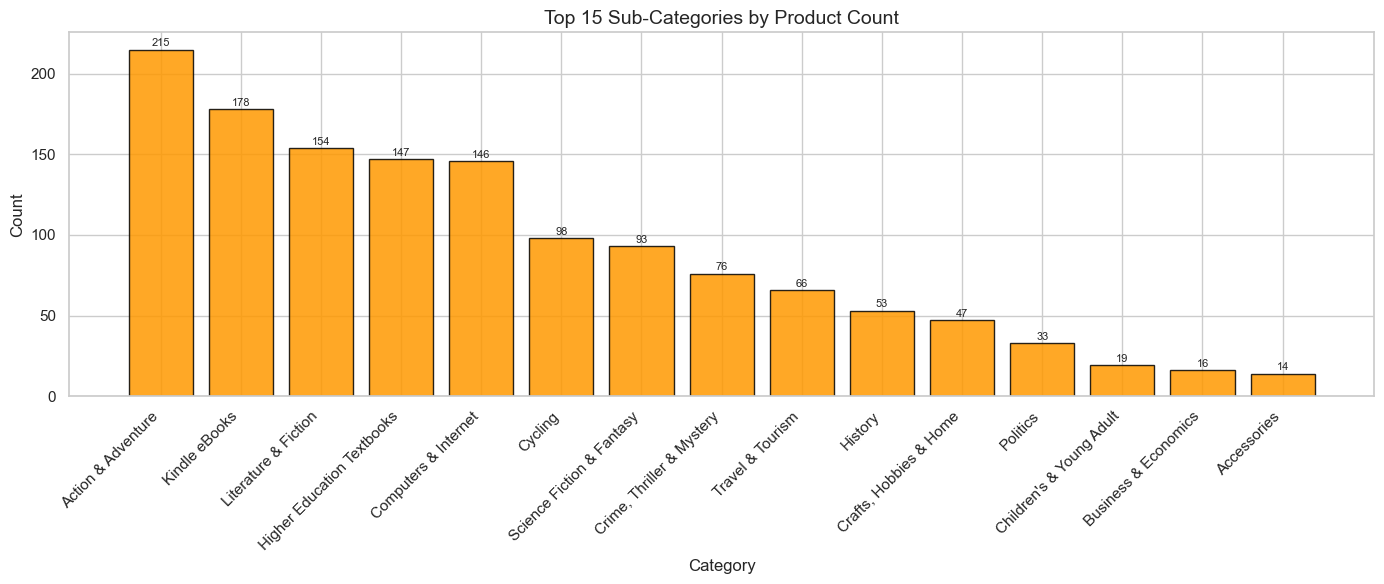

In [44]:
# ============================================================
# 🗂️ SECCIÓN 6 — Análisis de Categorías
# ============================================================
# Obtener las 15 subcategorías con mayor cantidad de productos
# value_counts() cuenta cuántas veces aparece cada categoría
# head(15) selecciona las 15 más frecuentes
top15_cat1 = df['category_1'].value_counts().head(15)
# Crear una figura para el gráfico
plt.figure(figsize=(14, 6))
# Generar gráfico de barras
bars = plt.bar(
    top15_cat1.index,      # Nombres de las subcategorías
    top15_cat1.values,     # Cantidad de productos por subcategoría
    color='#FF9900',       # Color de las barras
    edgecolor='black',     # Borde de las barras
    alpha=0.85             # Transparencia
)

# Agregar etiquetas con los valores encima de cada barra
for bar, val in zip(bars, top15_cat1.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,  # Posición horizontal
        bar.get_height() + 2,               # Posición vertical
        str(val),                           # Valor a mostrar
        ha='center',                        # Centrar texto
        fontsize=8
    )
# Configurar título del gráfico
plt.title('Top 15 Sub-Categories by Product Count')
# Etiqueta del eje X
plt.xlabel('Category')
# Etiqueta del eje Y
plt.ylabel('Count')
# Rotar etiquetas del eje X para mejorar la legibilidad
plt.xticks(rotation=45, ha='right')
# Ajustar automáticamente los márgenes y espacios
plt.tight_layout()
# Mostrar el gráfico
plt.show()

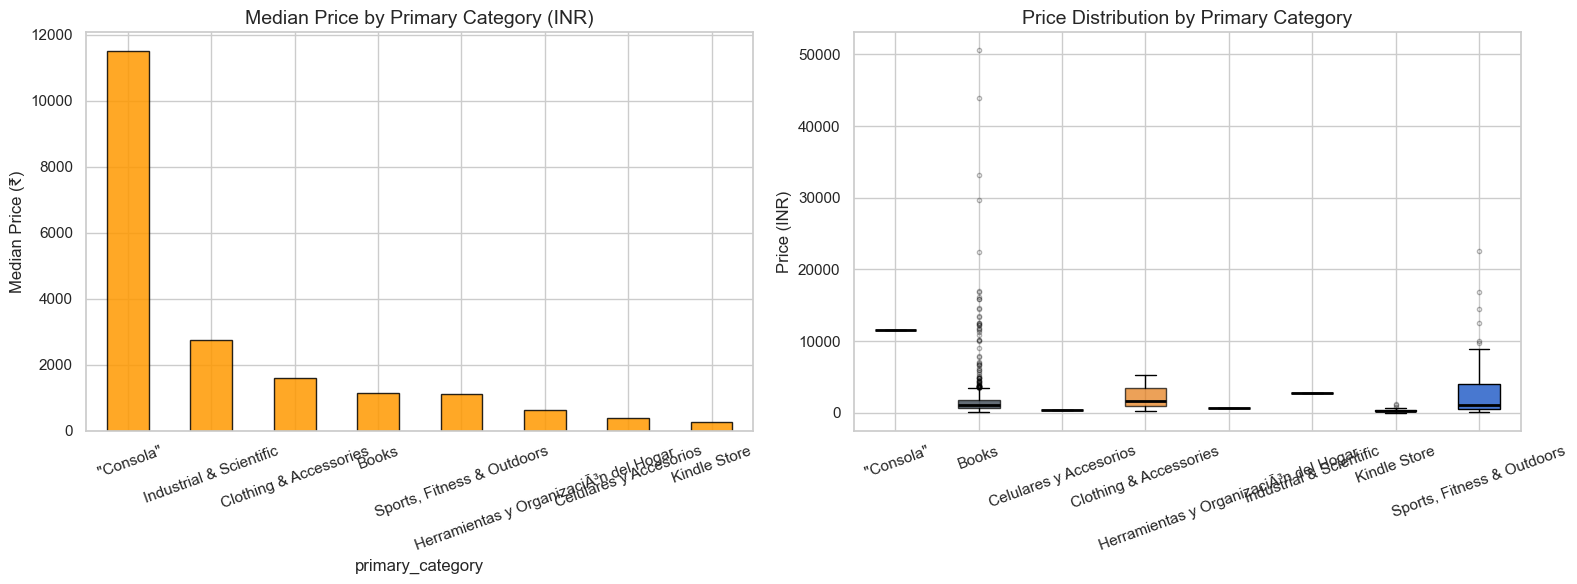

Price stats by primary category:
                                           mean   median  count
primary_category                                               
 "Consola"                              11499.0  11499.0      1
Books                                    1825.6   1145.0    955
Celulares y Accesorios                    399.0    399.0      1
Clothing & Accessories                   2249.2   1606.5      6
Herramientas y OrganizaciÃ³n del Hogar    622.5    622.5      1
Industrial & Scientific                  2738.0   2738.0      1
Kindle Store                              350.0    281.4     30
Sports, Fitness & Outdoors               2907.9   1125.0     93


In [43]:
# ============================================================
# 💰 Precio por Categoría Principal
# ============================================================
# Crear una figura con 2 gráficos (1 fila y 2 columnas)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# ============================================================
# Estadísticas de precios por categoría principal
# ============================================================
# Agrupar los datos por categoría principal y calcular:
# - Precio promedio (mean)
# - Precio mediano (median)
# - Cantidad de productos (count)
cat_price = (
    df_priced
    .groupby('primary_category')['price_clean']
    .agg(['mean', 'median', 'count'])
    .round(1)
)
# ============================================================
# Gráfico de barras: Precio mediano por categoría
# ============================================================
# Ordenar las categorías de mayor a menor según su precio mediano
cat_price['median'].sort_values(ascending=False).plot.bar(
    ax=axes[0],
    color='#FF9900',
    edgecolor='black',
    alpha=0.85
)
# Configuración del gráfico
axes[0].set_title('Median Price by Primary Category (INR)')
axes[0].set_ylabel('Median Price (₹)')
axes[0].tick_params(axis='x', rotation=20)
# ============================================================
# Boxplot: Distribución de precios por categoría
# ============================================================
# Crear una lista con los precios de cada categoría
cat_groups = [
    df_priced[df_priced['primary_category'] == c]['price_clean'].dropna()
    for c in cat_price.index
]

# Generar diagrama de caja para comparar la distribución
# de precios entre categorías
bp = axes[1].boxplot(
    cat_groups,
    labels=cat_price.index,
    patch_artist=True,
    medianprops=dict(color='black', lw=2),
    flierprops=dict(marker='o', markersize=3, alpha=0.3)
)
# Colores asignados a cada categoría
colors_cat = ['#FF9900', '#232F3E', '#146EB4', '#E47911', '#999']
# Aplicar colores a las cajas del boxplot
for patch, color in zip(bp['boxes'], colors_cat):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
# Configuración del gráfico
axes[1].set_title('Price Distribution by Primary Category')
axes[1].set_ylabel('Price (INR)')
axes[1].tick_params(axis='x', rotation=20)
# ============================================================
# Mostrar gráficos
# ============================================================
# Ajustar automáticamente los espacios entre gráficos
plt.tight_layout()
# Mostrar figura
plt.show()
# ============================================================
# Mostrar estadísticas por categoría
# ============================================================
print('Price stats by primary category:')
# Imprimir tabla con media, mediana y cantidad de productos
print(cat_price.to_string())

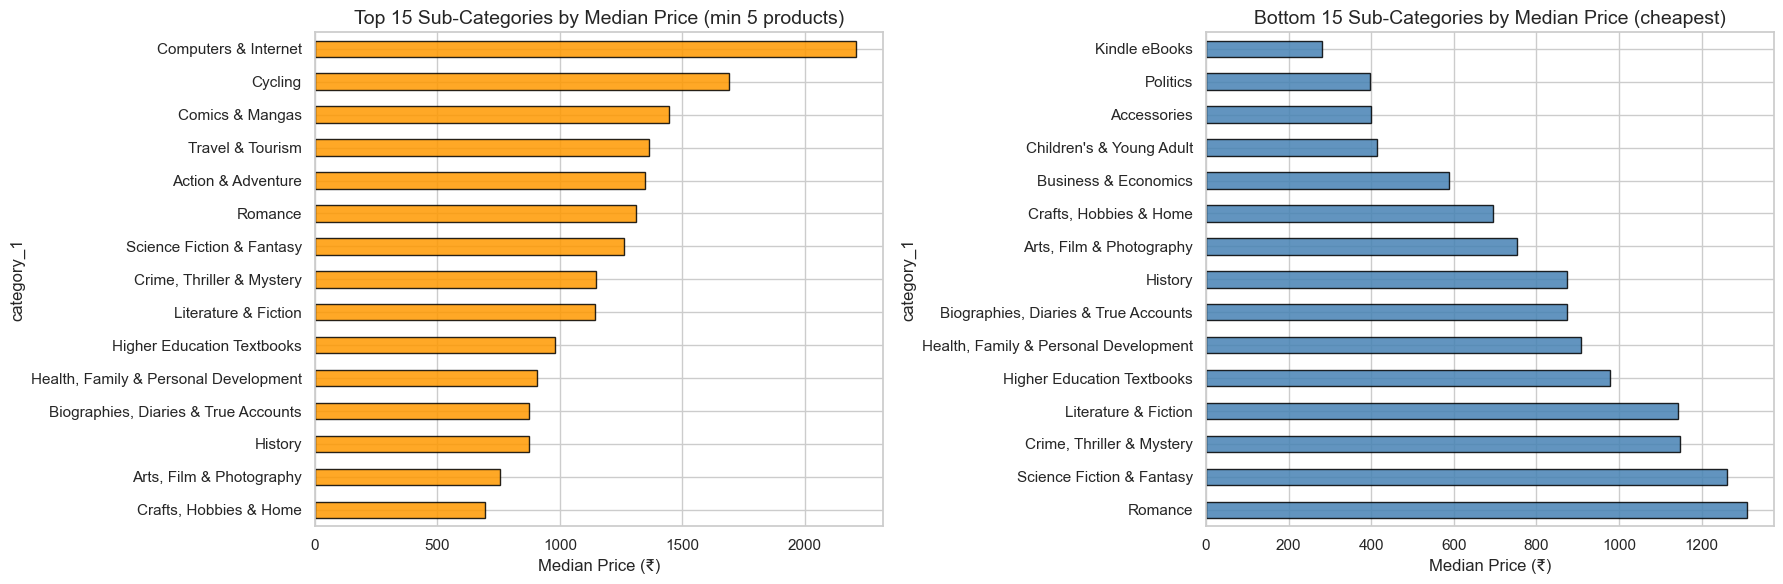

In [42]:
# ============================================================
# Top 15 y Bottom 15 Subcategorías por Precio Mediano
# ============================================================
# Agrupar los productos por subcategoría (category_1)
# y calcular:
# - Precio mediano (median)
# - Cantidad de productos (count)
# Se consideran únicamente subcategorías con al menos 5 productos
top_cat1_price = (
    df_priced
    .groupby('category_1')['price_clean']
    .agg(['median', 'count'])
    .query('count >= 5')
    .sort_values('median', ascending=False)
    .head(15)
)
# Crear una figura con 2 gráficos (1 fila y 2 columnas)
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
# ============================================================
# Top 15 subcategorías más caras
# ============================================================
# Crear gráfico de barras horizontales con las subcategorías
# que tienen el precio mediano más alto
top_cat1_price['median'].sort_values().plot.barh(
    ax=axes[0],
    color='#FF9900',
    edgecolor='black',
    alpha=0.85
)

# Configuración del gráfico
axes[0].set_title('Top 15 Sub-Categories by Median Price (min 5 products)')
axes[0].set_xlabel('Median Price (₹)')
# ============================================================
# Top 15 subcategorías más económicas
# ============================================================
# Obtener las subcategorías con menor precio mediano
# considerando únicamente aquellas con al menos 5 productos
bottom_cat1 = (
    df_priced
    .groupby('category_1')['price_clean']
    .agg(['median', 'count'])
    .query('count >= 5')
    .sort_values('median')
    .head(15)
)
# Crear gráfico de barras horizontales para las categorías más baratas
bottom_cat1['median'].sort_values(ascending=False).plot.barh(
    ax=axes[1],
    color='steelblue',
    edgecolor='black',
    alpha=0.85
)
# Configuración del gráfico
axes[1].set_title('Bottom 15 Sub-Categories by Median Price (cheapest)')
axes[1].set_xlabel('Median Price (₹)')
# ============================================================
# Mostrar gráficos
# ============================================================
# Ajustar automáticamente los espacios entre gráficos
plt.tight_layout()
# Mostrar figura
plt.show()

## 7.  Análisis de Disponibilidad (Availability Analysis)📦 <a id='s7'></a>

<div style="background:#f0fff0; padding:12px; border-left:4px solid #27ae60; border-radius:5px; color:#1e8449;">
<b>Pregunta clave:</b> ¿El estado de disponibilidad afecta el precio? ¿Es más probable que los productos premium estén agotados?
</div>

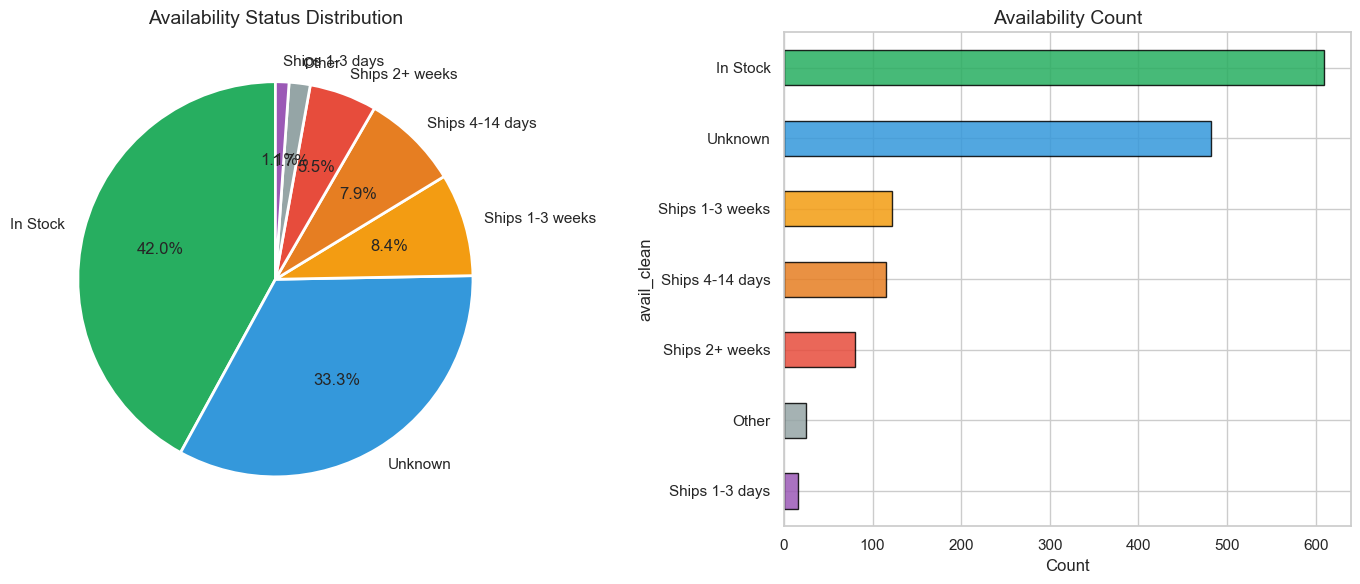

In [41]:
# ============================================================
# SECCIÓN 7 — Análisis de Disponibilidad
# ============================================================
# Contar cuántos productos existen en cada estado de disponibilidad
# (Disponible, Agotado, Stock limitado, etc.)
avail_counts = df['avail_clean'].value_counts()
# Definir una paleta de colores para los gráficos
avail_colors = [
    '#27ae60', '#3498db', '#f39c12', '#e67e22',
    '#e74c3c', '#95a5a6', '#9b59b6', '#1abc9c'
]
# Crear una figura con 2 gráficos (1 fila y 2 columnas)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
# ============================================================
# Gráfico circular (Pie Chart)
# ============================================================
# Mostrar la proporción de productos por estado de disponibilidad
axes[0].pie(
    avail_counts.values,                    # Cantidad de productos
    labels=avail_counts.index,              # Etiquetas de cada categoría
    colors=avail_colors[:len(avail_counts)],# Colores asignados
    autopct='%1.1f%%',                      # Mostrar porcentaje
    startangle=90,                          # Iniciar desde arriba
    wedgeprops=dict(
        edgecolor='white',                  # Borde blanco
        linewidth=2
    )
)
# Título del gráfico
axes[0].set_title('Availability Status Distribution')
# ============================================================
# Gráfico de barras horizontales
# ============================================================
# Ordenar los estados de disponibilidad por cantidad
# y generar gráfico de barras horizontales
avail_counts.sort_values().plot.barh(
    ax=axes[1],
    color=avail_colors[:len(avail_counts)][::-1],
    edgecolor='black',
    alpha=0.85
)
# Configuración del gráfico
axes[1].set_title('Availability Count')
axes[1].set_xlabel('Count')
# ===========================================================
# Mostrar gráficos
# ============================================================
# Ajustar automátcamente los espacios
plt.tight_layout()
# Mostrar figura
plt.show()

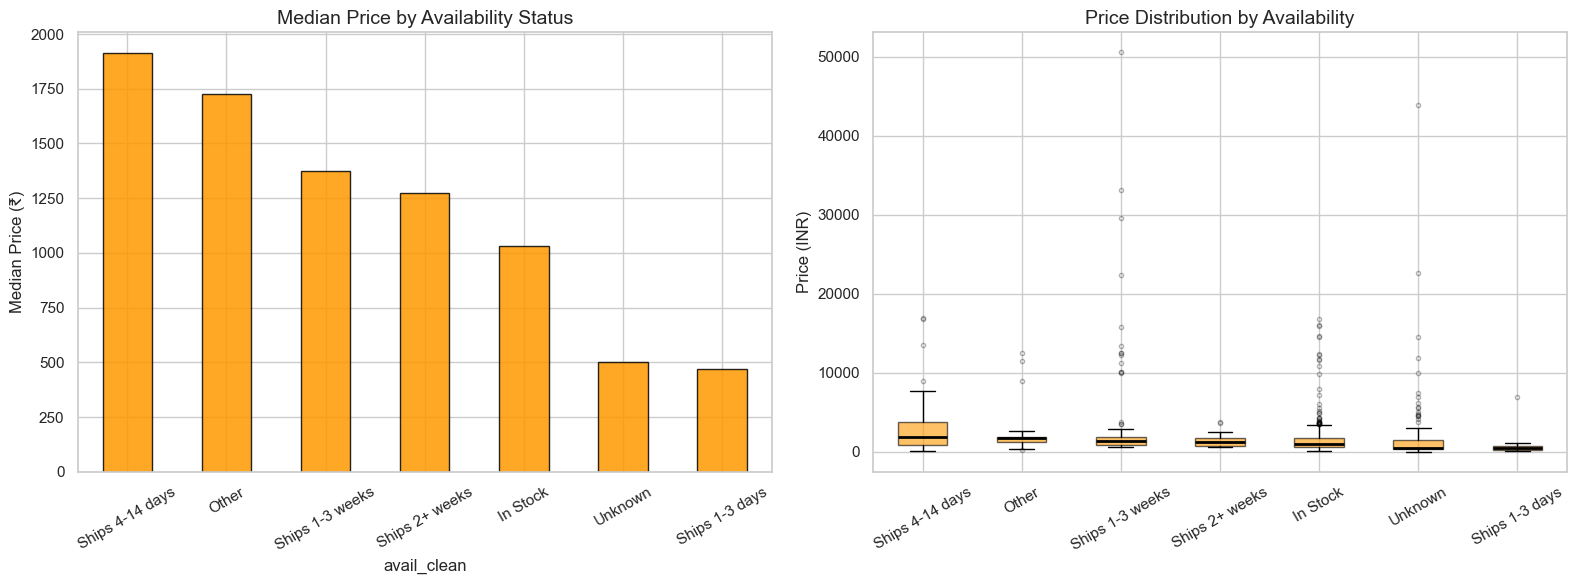

Price by availability:
                 median    mean  count
avail_clean                           
Ships 4-14 days  1912.3  2874.6    115
Other            1724.2  2644.9     24
Ships 1-3 weeks  1376.0  3210.8    122
Ships 2+ weeks   1273.0  1385.9     80
In Stock         1031.0  1493.4    601
Unknown           503.0  1879.4    135
Ships 1-3 days    469.0   874.9     16


In [40]:
# ============================================================
# Precio según el Estado de Disponibilidad
# ============================================================
# Agrupar los productos por estado de disponibilidad y calcular:
# - Precio mediano (median)
# - Precio promedio (mean)
# - Cantidad de productos (count)
avail_price = (
    df_priced
    .groupby('avail_clean')['price_clean']
    .agg(['median', 'mean', 'count'])
    .round(1)
)
# Filtrar únicamente los estados con al menos 5 productos
# y ordenar de mayor a menor según el precio mediano
avail_price = (
    avail_price[avail_price['count'] >= 5]
    .sort_values('median', ascending=False)
)

# Crear una figura con dos gráficos
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# ============================================================
# Gráfico de barras: Precio mediano por disponibilidad
# ===========================================================
# Mostrar el precio mediano de cada estado de disponibilidad
avail_price['median'].plot.bar(
    ax=axes[0],
    color='#FF9900',
    edgecolor='black',
    alpha=0.85
)
# Configuración del gráfico
axes[0].set_title('Median Price by Availability Status')
axes[0].set_ylabel('Median Price (₹)')
axes[0].tick_params(axis='x', rotation=30)
# ============================================================
# Boxplot: Distribución de precios por disponibilidad
# ============================================================
# Crear una lista con los precios correspondientes
# a cada estado de disponibilidad
avail_groups = [
    df_priced[df_priced['avail_clean'] == a]['price_clean'].dropna()
    for a in avail_price.index
]
# Generar diagrama de caja para comparar la distribución
# de precios entre los diferentes estados
bp = axes[1].boxplot(
    avail_groups,
    labels=avail_price.index,
    patch_artist=True,
    medianprops=dict(color='black', lw=2),
    flierprops=dict(marker='o', markersize=3, alpha=0.3)
)
# Aplicar color a las cajas del boxplot
for patch in bp['boxes']:
    patch.set_facecolor('#FF9900')
    patch.set_alpha(0.6)
# Configuración del gráfico
axes[1].set_title('Price Distribution by Availability')
axes[1].set_ylabel('Price (INR)')
axes[1].tick_params(axis='x', rotation=30)
# Ajustar automáticamente los espacios
plt.tight_layout()
# Mostrar los gráficos
plt.show()
# ============================================================
# Mostrar estadísticas de precios por disponibilidad
# ============================================================
print('Price by availability:')
# Imprimir tabla con mediana, media y cantidad de productos
print(avail_price.to_string())

## 8. Análisis de Correlación y Análisis Bivariado (Correlation & Bivariate Analysis)🔗 <a id='s8'></a>

<div style="background:#eaf4ff; padding:12px; border-left:4px solid #0066cc; border-radius:5px; color:#0066cc;">
<b>Pregunta clave:</b> ¿Qué características están más correlacionadas con el precio? ¿La longitud del nombre predice el precio?
</div>


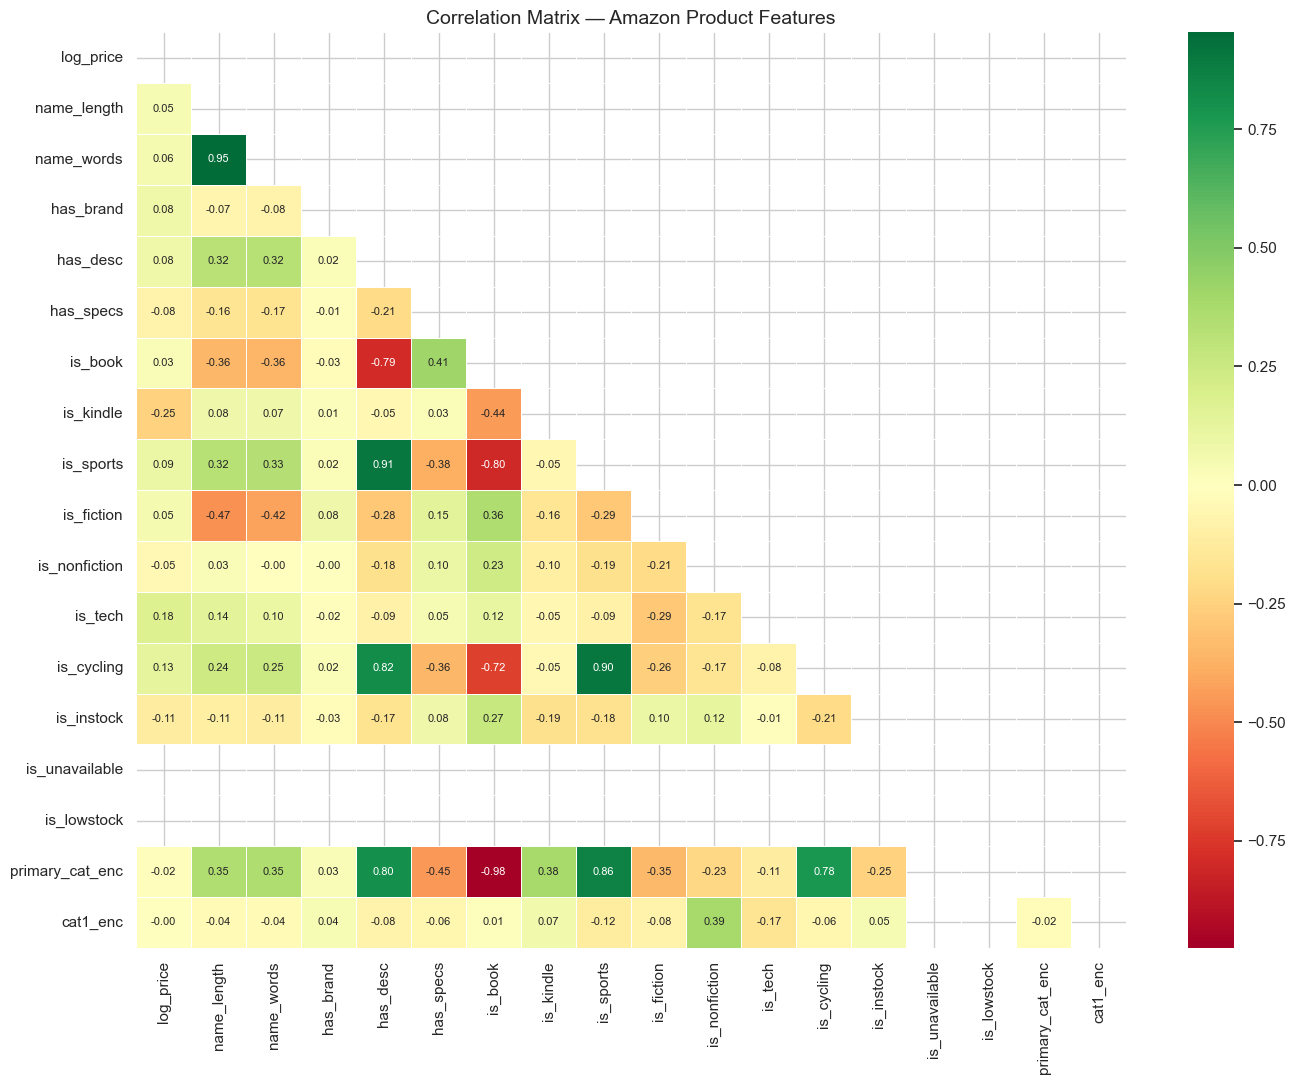

Top correlations with log_price:
is_tech            0.175532
is_cycling         0.125795
is_sports          0.090982
has_brand          0.083593
has_desc           0.080033
name_words         0.055646
is_fiction         0.051064
name_length        0.049355
is_book            0.029688
cat1_enc          -0.002107
primary_cat_enc   -0.018140
is_nonfiction     -0.045158
has_specs         -0.078165
is_instock        -0.111915
is_kindle         -0.245963
is_unavailable          NaN
is_lowstock             NaN


In [38]:
# ============================================================
# 🔗 SECCIÓN 8 — Análisis de Correlación
# ============================================================

# Seleccionar las variables numéricas y categóricas codificadas
# que serán utilizadas para analizar las relaciones entre ellas
corr_cols = [
    'log_price', 'name_length', 'name_words', 'has_brand',
    'has_desc', 'has_specs', 'is_book', 'is_kindle',
    'is_sports', 'is_fiction', 'is_nonfiction', 'is_tech',
    'is_cycling', 'is_instock', 'is_unavailable',
    'is_lowstock', 'primary_cat_enc', 'cat1_enc'
]

# Calcular la matriz de correlación entre las variables seleccionadas
corr = df_priced[corr_cols].corr()

# Crear una máscara para ocultar la mitad superior de la matriz
# y evitar mostrar información duplicada
mask = np.triu(np.ones_like(corr, dtype=bool))

# ============================================================
# Mapa de calor (Heatmap) de correlaciones
# ============================================================

# Crear figura para visualizar las correlaciones
plt.figure(figsize=(14, 11))

# Generar mapa de calor
# Los colores indican la fuerza y dirección de la correlación:
# Verde = correlación positiva
# Rojo = correlación negativa
# Amarillo = correlación cercana a cero
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    linewidths=0.4,
    annot_kws={'size': 8}
)

# Configuración del gráfico
plt.title('Correlation Matrix — Amazon Product Features', fontsize=14)

# Ajustar espacios automáticamente
plt.tight_layout()

# Mostrar gráfico
plt.show()

# ============================================================
# Correlaciones con el precio
# ============================================================

# Mostrar las variables más relacionadas con el precio
# (log_price), excluyendo la autocorrelación
print('Top correlations with log_price:')

print(
    corr['log_price']
    .drop('log_price')
    .sort_values(ascending=False)
    .to_string()
)

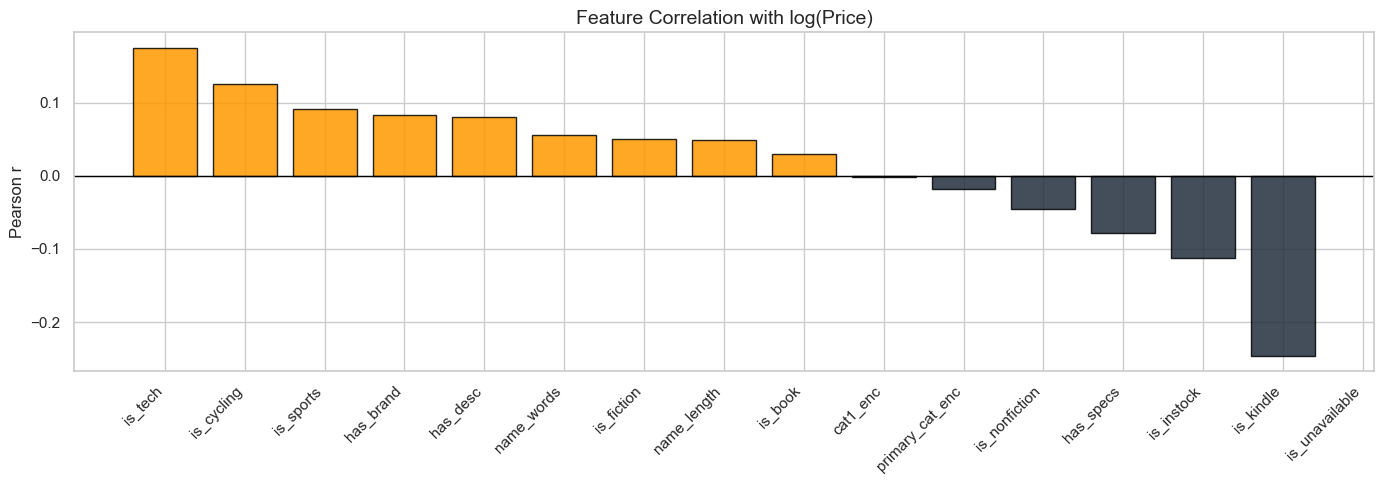

In [30]:
# Se calculan las correlaciones de todas las variables con 'log_price'
# Se eliminan los valores de 'log_price' consigo mismo
# Luego se ordenan de mayor a menor correlación
feat_corr = corr['log_price'].drop('log_price').sort_values(ascending=False)

# Se crea una figura para el gráfico con tamaño 14x5 pulgadas
plt.figure(figsize=(14, 5))

# Se definen los colores de las barras:
# Naranja (#FF9900) si la correlación es positiva
# Azul oscuro (#232F3E) si la correlación es negativa
colors_fc = ['#FF9900' if v > 0 else '#232F3E' for v in feat_corr.values]

# Se crea un gráfico de barras con:
# - variables en el eje X
# - valores de correlación en el eje Y
# - color personalizado por signo
# - borde negro y transparencia del 85%
plt.bar(feat_corr.index, feat_corr.values, color=colors_fc, edgecolor='black', alpha=0.85)

# Se agrega una línea horizontal en 0 para distinguir correlaciones positivas y negativas
plt.axhline(0, color='black', lw=1)

# Título del gráfico
plt.title('Feature Correlation with log(Price)')

# Etiqueta del eje Y
plt.ylabel('Pearson r')

# Se rotan las etiquetas del eje X para mejor legibilidad
plt.xticks(rotation=45, ha='right')

# Ajusta automáticamente los márgenes para que no se encimen los elementos
plt.tight_layout()

# Muestra el gráfico final
plt.show()

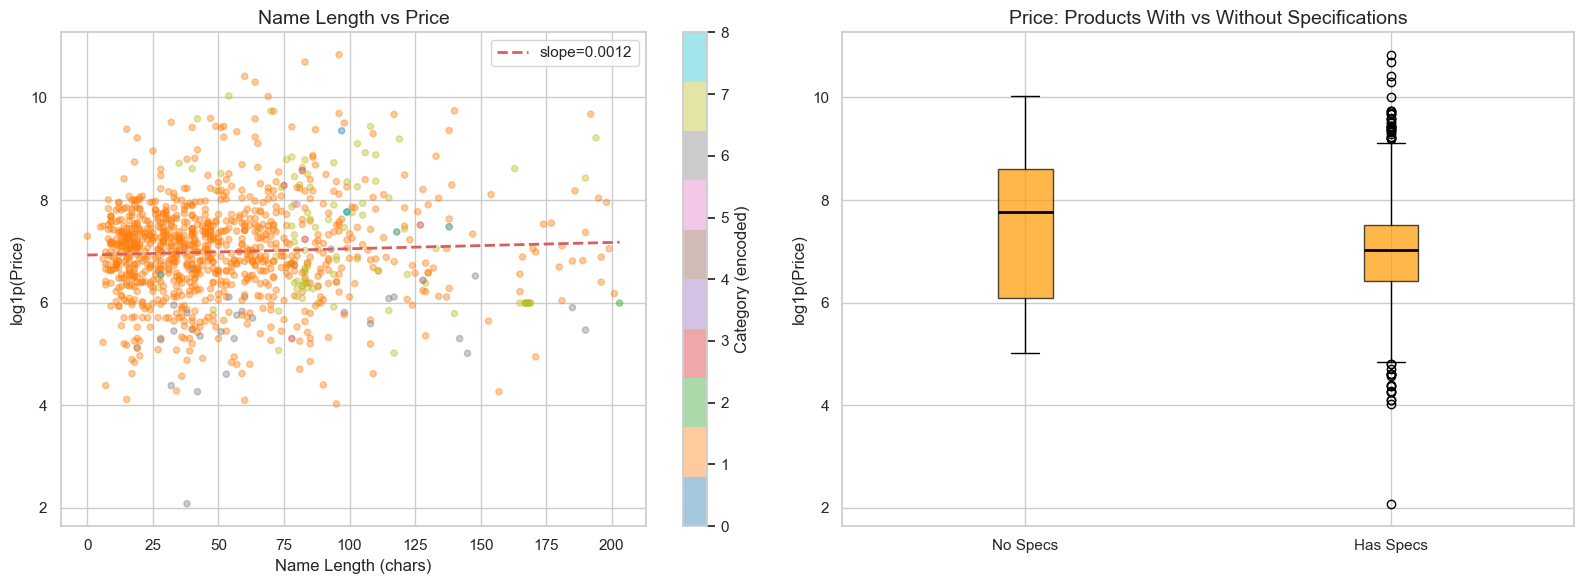

In [31]:
# Se crean 2 subgráficas en una fila (1x2) con tamaño 16x6
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# =========================
# GRÁFICO 1: Scatter plot
# =========================

# Se crea un scatter plot:
# - Eje X: longitud del nombre del producto
# - Eje Y: log del precio
# - Color: categoría codificada (primary_cat_enc)
# - alpha: transparencia (0.4 para ver densidad)
# - s: tamaño de los puntos
sc = axes[0].scatter(
    df_priced['name_length'],
    df_priced['log_price'],
    c=df_priced['primary_cat_enc'],
    cmap='tab10',
    alpha=0.4,
    s=20
)

# Se agrega barra de color para interpretar las categorías
plt.colorbar(sc, ax=axes[0], label='Category (encoded)')

# Se ajusta una línea de regresión lineal (mínimos cuadrados)
# m = pendiente, b = intercepto
m, b = np.polyfit(df_priced['name_length'], df_priced['log_price'], 1)

# Se generan valores X para dibujar la línea de tendencia
x = np.linspace(0, df_priced['name_length'].max(), 100)

# Se dibuja la línea de tendencia en rojo punteado
axes[0].plot(x, m*x + b, 'r--', lw=2, label=f'slope={m:.4f}')

# Etiquetas del eje X y Y
axes[0].set_xlabel('Name Length (chars)')
axes[0].set_ylabel('log1p(Price)')

# Título del gráfico
axes[0].set_title('Name Length vs Price')

# Se muestra la leyenda (pendiente de la regresión)
axes[0].legend()

# =========================
# GRÁFICO 2: Boxplot
# =========================

# Se comparan dos grupos:
# - Productos sin especificaciones (has_specs == 0)
# - Productos con especificaciones (has_specs == 1)
# Se aplica log1p al precio para normalizarlo

axes[1].boxplot(
    [
        np.log1p(df_priced[df_priced['has_specs'] == 0]['price_clean']),
        np.log1p(df_priced[df_priced['has_specs'] == 1]['price_clean'])
    ],
    labels=['No Specs', 'Has Specs'],
    patch_artist=True,
    boxprops=dict(facecolor='#FF9900', alpha=0.7),
    medianprops=dict(color='black', lw=2)
)

# Título del segundo gráfico
axes[1].set_title('Price: Products With vs Without Specifications')

# Etiqueta del eje Y
axes[1].set_ylabel('log1p(Price)')

# Ajusta el layout para evitar solapamientos
plt.tight_layout()

# Muestra ambos gráficos
plt.show()

## 9. Prueba de hipótesis estadística 🧪 <a id='s9'></a>

<div style="background:#fff9c4; padding:12px; border-left:4px solid #fbc02d; border-radius:5px; color:#8a6d00;">
<b>Prueba de Hipótesis Estadística:</b> Utilizamos pruebas no paramétricas (Kruskal-Wallis y Mann-Whitney U) porque el precio presenta una distribución altamente sesgada y no normal. Se empleó un nivel de significancia de α = 0.05.
</div>

In [37]:
# ============================================================
# SECCIÓN 9 — Prueba de Hipótesis Estadística
# ============================================================
alpha = 0.05

def mw_test(nombre, a, b, etiqueta_a, etiqueta_b):
    u, p = mannwhitneyu(a.dropna(), b.dropna(), alternative='two-sided')
    print(f'{nombre}')
    print(f'  {etiqueta_a}: n={len(a.dropna())}, mediana=₹{a.median():.0f}')
    print(f'  {etiqueta_b}: n={len(b.dropna())}, mediana=₹{b.median():.0f}')
    print(f'  Mann-Whitney U={u:.0f}, p={p:.6f}')
    print(f'  RESULTADO: {"✅ RECHAZAR H0 — Diferencia significativa." if p < alpha else "❌ NO SE RECHAZA H0."}')
    print()
    return p

# H1: Precio entre categorías principales — Kruskal-Wallis
cat_groups_kw = [df_priced[df_priced['primary_category']==c]['price_clean'].dropna()
                 for c in df_priced['primary_category'].unique()
                 if len(df_priced[df_priced['primary_category']==c]) >= 5]

cat_labels_kw = [c for c in df_priced['primary_category'].unique()
                 if len(df_priced[df_priced['primary_category']==c]) >= 5]

h1, p1 = kruskal(*cat_groups_kw)

print('H1: Precio entre Categorías Principales — Kruskal-Wallis')
for label, g in zip(cat_labels_kw, cat_groups_kw):
    print(f'  {label:35s}: n={len(g)}, mediana=₹{g.median():.0f}')

print(f'  H={h1:.4f}, p={p1:.6f}')
print(f'  RESULTADO: {"✅ RECHAZAR H0 — El precio difiere entre categorías." if p1 < alpha else "❌ NO SE RECHAZA H0."}')
print()

# H2: Libros vs Productos Deportivos
p2 = mw_test(
    'H2: Precio de Libros vs Productos Deportivos',
    df_priced[df_priced['is_book']==1]['price_clean'],
    df_priced[df_priced['is_sports']==1]['price_clean'],
    'Libros',
    'Deportes'
)

# H3: En existencia vs No disponible
p3 = mw_test(
    'H3: Precio de Productos en Existencia vs No Disponibles',
    df_priced[df_priced['is_instock']==1]['price_clean'],
    df_priced[df_priced['is_unavailable']==1]['price_clean'],
    'En Existencia',
    'No Disponible'
)

# H4: Longitud del nombre vs precio — Spearman
rho4, p4 = spearmanr(df_priced['name_length'], df_priced['price_clean'])

print('H4: Longitud del Nombre vs Precio — Correlación de Spearman')
print(f'  rho={rho4:.4f}, p={p4:.6f}')
print(f'  RESULTADO: {"✅ RECHAZAR H0 — Correlación significativa." if p4 < alpha else "❌ NO SE RECHAZA H0."}')
print()

# H5: Con especificaciones vs Sin especificaciones
p5 = mw_test(
    'H5: Productos con Especificaciones vs Sin Especificaciones',
    df_priced[df_priced['has_specs']==1]['price_clean'],
    df_priced[df_priced['has_specs']==0]['price_clean'],
    'Con Especificaciones',
    'Sin Especificaciones'
)

H1: Precio entre Categorías Principales — Kruskal-Wallis
  Books                              : n=955, mediana=₹1145
  Sports, Fitness & Outdoors         : n=93, mediana=₹1125
  Kindle Store                       : n=30, mediana=₹281
  Clothing & Accessories             : n=6, mediana=₹1606
  H=55.8663, p=0.000000
  RESULTADO: ✅ RECHAZAR H0 — El precio difiere entre categorías.

H2: Precio de Libros vs Productos Deportivos
  Libros: n=955, mediana=₹1145
  Deportes: n=93, mediana=₹1125
  Mann-Whitney U=40247, p=0.135443
  RESULTADO: ❌ NO SE RECHAZA H0.

H3: Precio de Productos en Existencia vs No Disponibles
  En Existencia: n=601, mediana=₹1031
  No Disponible: n=0, mediana=₹nan
  Mann-Whitney U=nan, p=nan
  RESULTADO: ❌ NO SE RECHAZA H0.

H4: Longitud del Nombre vs Precio — Correlación de Spearman
  rho=0.0370, p=0.221764
  RESULTADO: ❌ NO SE RECHAZA H0.

H5: Productos con Especificaciones vs Sin Especificaciones
  Con Especificaciones: n=1067, mediana=₹1116
  Sin Especificaciones: n=

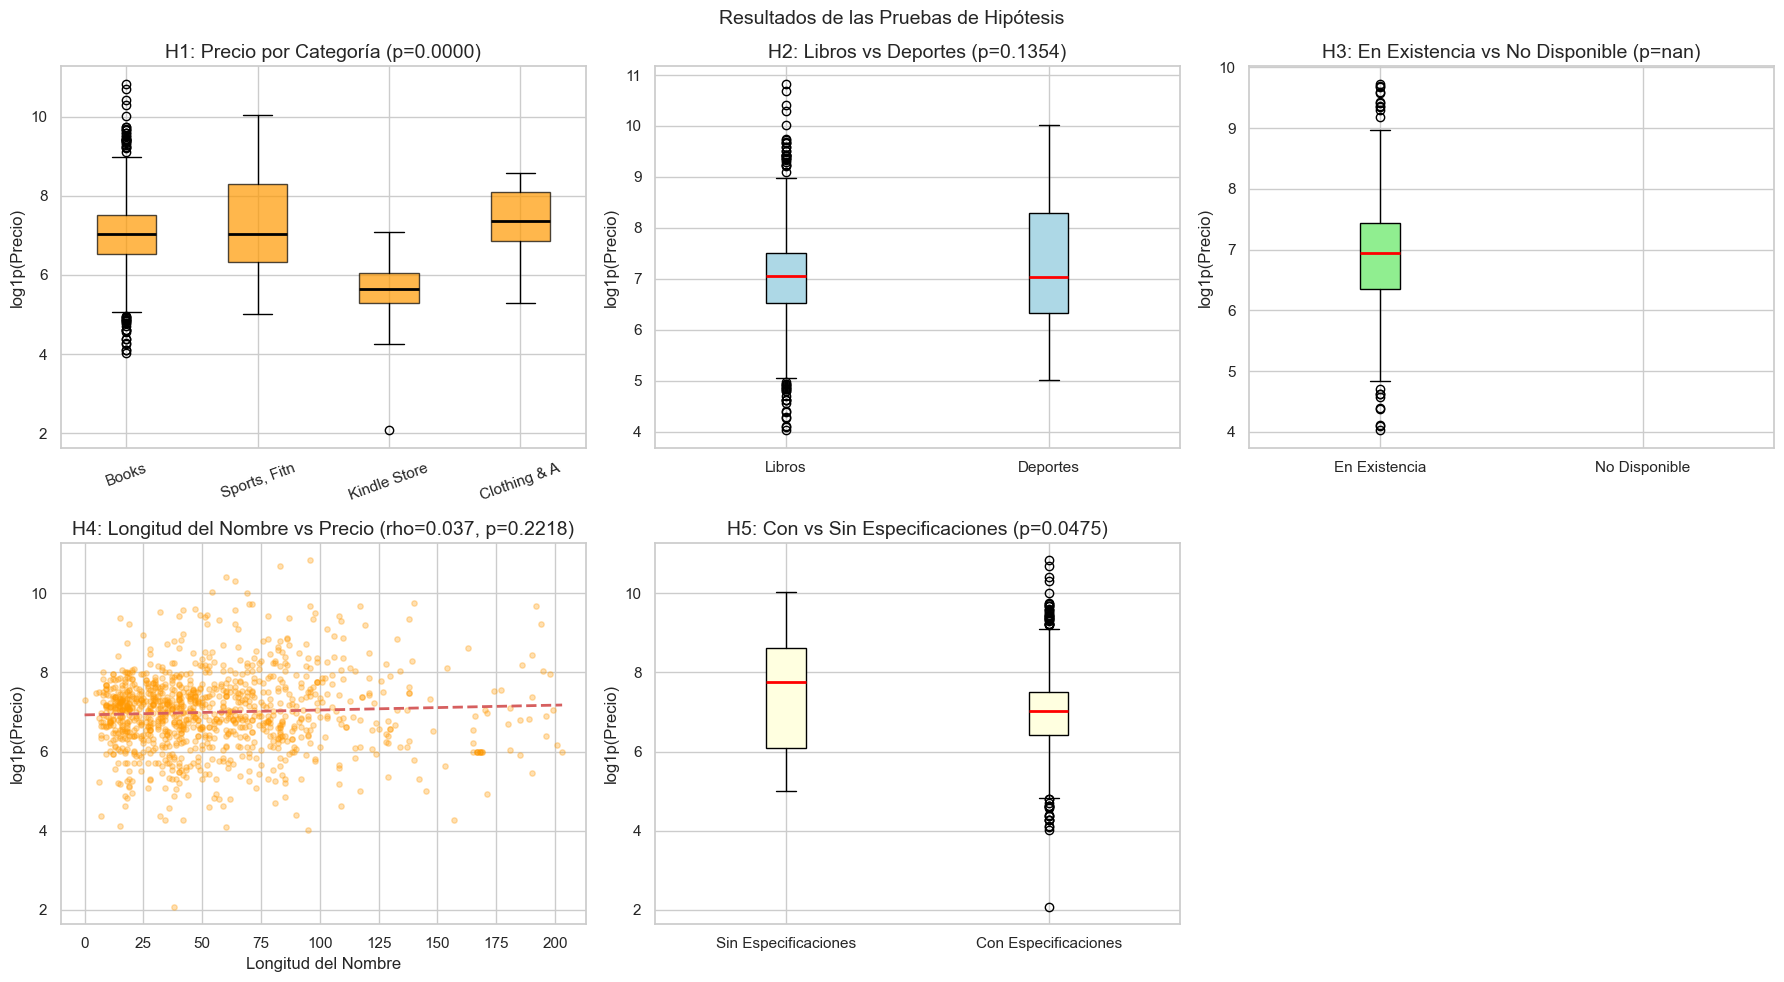

In [33]:
# Visualizar resultados de las pruebas de hipótesis
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# H1
axes[0,0].boxplot(
    [np.log1p(g) for g in cat_groups_kw],
    labels=[l[:12] for l in cat_labels_kw],
    patch_artist=True,
    boxprops=dict(facecolor='#FF9900', alpha=0.7),
    medianprops=dict(color='black', lw=2)
)
axes[0,0].set_title(f'H1: Precio por Categoría (p={p1:.4f})')
axes[0,0].set_ylabel('log1p(Precio)')
axes[0,0].tick_params(axis='x', rotation=20)

# H2
axes[0,1].boxplot(
    [np.log1p(df_priced[df_priced['is_book']==1]['price_clean']),
     np.log1p(df_priced[df_priced['is_sports']==1]['price_clean'])],
    labels=['Libros', 'Deportes'],
    patch_artist=True,
    boxprops=dict(facecolor='lightblue'),
    medianprops=dict(color='red', lw=2)
)
axes[0,1].set_title(f'H2: Libros vs Deportes (p={p2:.4f})')
axes[0,1].set_ylabel('log1p(Precio)')

# H3
axes[0,2].boxplot(
    [np.log1p(df_priced[df_priced['is_instock']==1]['price_clean']),
     np.log1p(df_priced[df_priced['is_unavailable']==1]['price_clean'])],
    labels=['En Existencia', 'No Disponible'],
    patch_artist=True,
    boxprops=dict(facecolor='lightgreen'),
    medianprops=dict(color='red', lw=2)
)
axes[0,2].set_title(f'H3: En Existencia vs No Disponible (p={p3:.4f})')
axes[0,2].set_ylabel('log1p(Precio)')

# H4
axes[1,0].scatter(
    df_priced['name_length'],
    df_priced['log_price'],
    alpha=0.3,
    color='#FF9900',
    s=15
)

m, b = np.polyfit(df_priced['name_length'], df_priced['log_price'], 1)
x = np.linspace(0, df_priced['name_length'].max(), 100)

axes[1,0].plot(x, m*x+b, 'r--', lw=2)
axes[1,0].set_title(
    f'H4: Longitud del Nombre vs Precio (rho={rho4:.3f}, p={p4:.4f})'
)
axes[1,0].set_xlabel('Longitud del Nombre')
axes[1,0].set_ylabel('log1p(Precio)')

# H5
axes[1,1].boxplot(
    [np.log1p(df_priced[df_priced['has_specs']==0]['price_clean']),
     np.log1p(df_priced[df_priced['has_specs']==1]['price_clean'])],
    labels=['Sin Especificaciones', 'Con Especificaciones'],
    patch_artist=True,
    boxprops=dict(facecolor='lightyellow'),
    medianprops=dict(color='red', lw=2)
)
axes[1,1].set_title(f'H5: Con vs Sin Especificaciones (p={p5:.4f})')
axes[1,1].set_ylabel('log1p(Precio)')

# Ocultar el último gráfico vacío
axes[1,2].set_visible(False)

plt.suptitle('Resultados de las Pruebas de Hipótesis', fontsize=14)
plt.tight_layout()
plt.show()

## 10 .ML Problem Framing (Planteamiento del Problema de Aprendizaje Automático)🎯 <a id='s9'></a>

<div style="background:#eaf4ff; padding:12px; border-left:4px solid #0066cc; border-radius:5px; color:#0066cc;">
<b>Planteamiento del Problema de Aprendizaje Automático 🎯:</b> 
Predecir el precio del producto (en escala logarítmica) utilizando la categoría, la longitud del nombre, la disponibilidad y diversos indicadores de características. 
<br><br>
<b>¿Por qué utilizar el logaritmo del precio?</b> 
El precio original presenta una distribución fuertemente sesgada hacia la derecha. La transformación logarítmica lo hace más cercano a una distribución normal y evita que los valores atípicos de productos muy costosos dominen la función de pérdida del modelo.
</div>

✅ Tamaño del conjunto de datos para ML : (1093, 20)
✅ Número de características            : 18

Entrenamiento: 874 | Prueba: 219


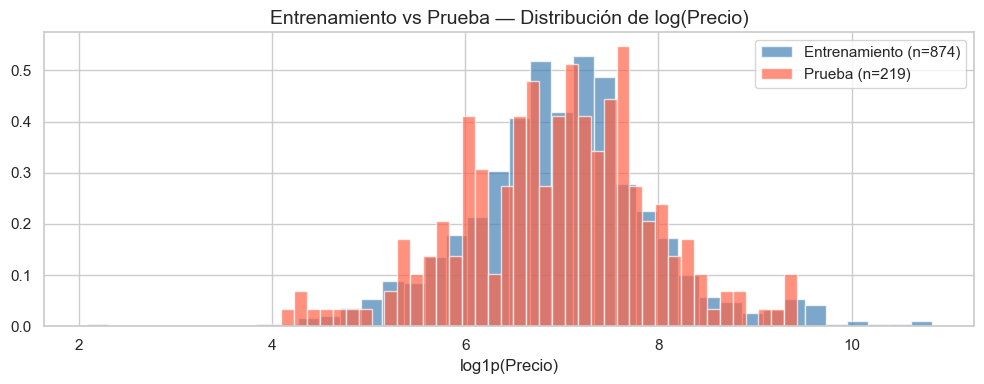

✅ Las distribuciones son similares — buena división de los datos.


In [36]:
# ============================================================
# SECCIÓN 10 — Planteamiento del Problema de Aprendizaje Automático
# ============================================================

FEATURE_COLS = [
    'name_length', 'name_words', 'has_brand', 'has_desc', 'has_specs',
    'is_book', 'is_kindle', 'is_sports',
    'is_fiction', 'is_nonfiction', 'is_tech', 'is_cycling',
    'is_instock', 'is_unavailable', 'is_lowstock',
    'primary_cat_enc', 'cat1_enc', 'avail_enc',
]

TARGET = 'log_price'

df_ml = df_priced[FEATURE_COLS + [TARGET, 'price_clean']].dropna().copy()

print(f'✅ Tamaño del conjunto de datos para ML : {df_ml.shape}')
print(f'✅ Número de características            : {len(FEATURE_COLS)}')

X = df_ml[FEATURE_COLS]
y = df_ml[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'\nEntrenamiento: {len(X_train):,} | Prueba: {len(X_test):,}')

# Visualizar la división de los datos
fig, ax = plt.subplots(figsize=(10, 4))

ax.hist(
    y_train,
    bins=40,
    color='steelblue',
    alpha=0.7,
    label=f'Entrenamiento (n={len(y_train)})',
    density=True
)

ax.hist(
    y_test,
    bins=40,
    color='tomato',
    alpha=0.7,
    label=f'Prueba (n={len(y_test)})',
    density=True
)

ax.set_title('Entrenamiento vs Prueba — Distribución de log(Precio)')
ax.set_xlabel('log1p(Precio)')
ax.legend()

plt.tight_layout()
plt.show()

print('✅ Las distribuciones son similares — buena división de los datos.')

## 11. Marco de selección de modelos 🧠 <a id='s11'></a>

| Modelo | Fortalezas | Debilidades | Ideal para |
|---|---|---|---|
| **Regresión lineal** | Rápida, interpretable | Asume linealidad | Línea base |
| **Regresión Ridge** | Maneja multicolinealidad | Sigue siendo lineal | Variables correlacionadas |
| **Regresión Lasso** | Selección de variables integrada | Puede anular variables útiles | Variables dispersas |
| **Random Forest** | No lineal, robusto | Menos interpretable | Patrones complejos |
| **XGBoost / GBM** | Mejor precisión | Requiere ajuste | Datos tabulares |

### Métricas de evaluación
- **MAE** — Error absoluto medio en escala logarítmica (menor = mejor)
- **RMSE** — Raíz del error cuadrático medio (penaliza errores grandes)
- **R²** — Varianza explicada (mayor = mejor, máximo 1.0)
- **MAE (₹)** — Reconvertido a INR para interpretación de negocio


In [35]:
# ============================================================
# SECCIÓN 11 — Ayudantes de evaluación
# ============================================================
results = {}

def eval_model(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mae_inr = mean_absolute_error(np.expm1(y_true), np.expm1(y_pred))
    print(f'  📊 {name}:')
    print(f'     MAE (log)  = {mae:.4f}  |  MAE (₹) = ₹{mae_inr:,.0f}')
    print(f'     RMSE (log) = {rmse:.4f}  |  R²      = {r2:.4f}')
    results[name] = {'MAE_log': round(mae,4), 'RMSE_log': round(rmse,4),
                     'R2': round(r2,4), 'MAE_INR': round(mae_inr,0)}
    return y_pred

print('✅ Ayudantes de evaluación listos.')

✅ Ayudantes de evaluación listos.


## 12. Modelos de regresión — Predicción el precio de Amazon 💰 <a id='s12'></a>

Entrenamos **5 modelos** y los comparamos en el mismo conjunto de prueba.


In [34]:
# ============================================================
# SECCIÓN 12 — Entrenamiento de Todos los Modelos
# ============================================================
print('='*60)
print('ENTRENAMIENTO DE TODOS LOS MODELOS')
print('='*60)

# 1. Regresión Lineal
lr = LinearRegression()
lr.fit(X_train_s, y_train)
lr_pred = eval_model('Regresión Lineal', y_test, lr.predict(X_test_s))

# 2. Regresión Ridge
ridge = Ridge(alpha=10.0)
ridge.fit(X_train_s, y_train)
ridge_pred = eval_model('Regresión Ridge', y_test, ridge.predict(X_test_s))

# 3. Regresión Lasso
lasso = Lasso(alpha=0.01, max_iter=5000)
lasso.fit(X_train_s, y_train)
lasso_pred = eval_model('Regresión Lasso', y_test, lasso.predict(X_test_s))

# 4. Bosque Aleatorio (Random Forest)
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
rf_pred = eval_model('Random Forest', y_test, rf.predict(X_test))

# 5. XGBoost / Gradient Boosting
if XGB_AVAILABLE:
    xgb_model = xgb.XGBRegressor(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbosity=0
    )
    xgb_model.fit(X_train, y_train)
    xgb_pred = eval_model('XGBoost', y_test, xgb_model.predict(X_test))
else:
    gbm = GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        random_state=42
    )
    gbm.fit(X_train, y_train)
    xgb_pred = eval_model('Gradient Boosting', y_test, gbm.predict(X_test))

ENTRENAMIENTO DE TODOS LOS MODELOS
  📊 Regresión Lineal:
     MAE (log)  = 0.7099  |  MAE (₹) = ₹1,045
     RMSE (log) = 0.9280  |  R²      = 0.1237
  📊 Regresión Ridge:
     MAE (log)  = 0.7074  |  MAE (₹) = ₹1,034
     RMSE (log) = 0.9196  |  R²      = 0.1395
  📊 Regresión Lasso:
     MAE (log)  = 0.7065  |  MAE (₹) = ₹1,028
     RMSE (log) = 0.9128  |  R²      = 0.1522
  📊 Random Forest:
     MAE (log)  = 0.6408  |  MAE (₹) = ₹946
     RMSE (log) = 0.8482  |  R²      = 0.2679
  📊 Gradient Boosting:
     MAE (log)  = 0.7065  |  MAE (₹) = ₹1,053
     RMSE (log) = 0.9288  |  R²      = 0.1220


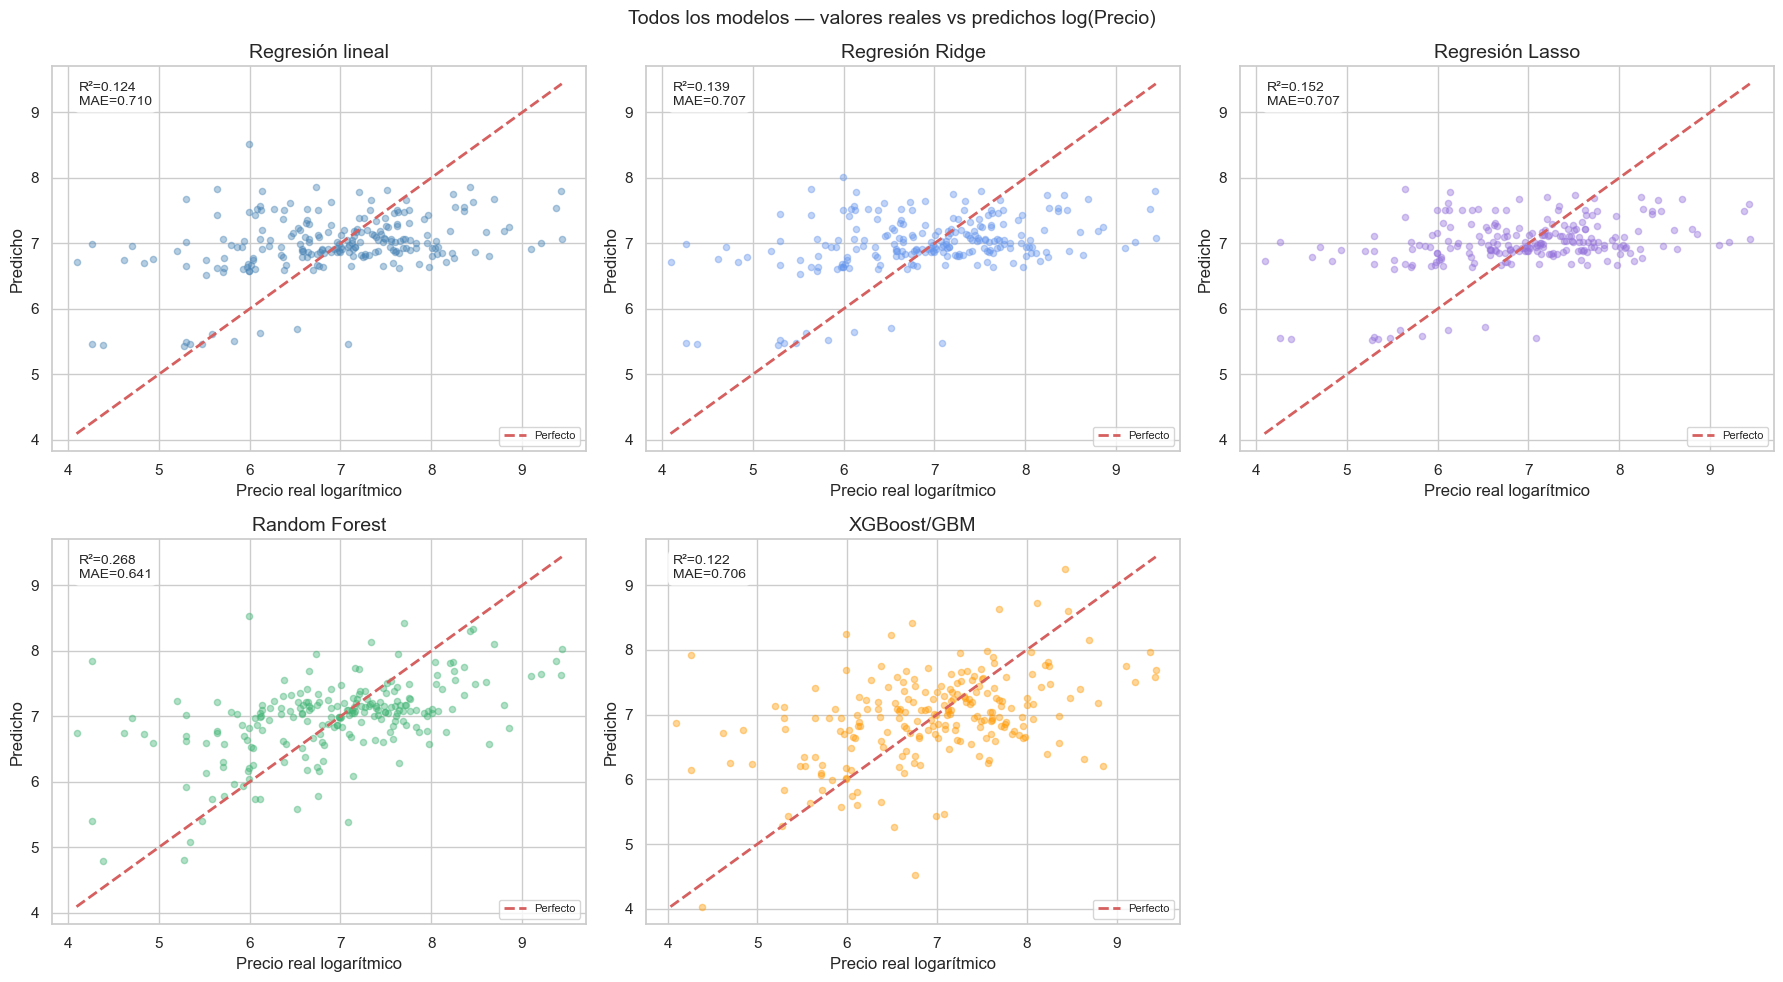

In [20]:
# Valores reales vs predichos — todos los modelos
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
preds_all = [('Regresión lineal', lr_pred, 'steelblue'),
             ('Regresión Ridge',  ridge_pred, 'cornflowerblue'),
             ('Regresión Lasso',  lasso_pred, 'mediumpurple'),
             ('Random Forest',     rf_pred,    'mediumseagreen'),
             ('XGBoost/GBM',       xgb_pred,   '#FF9900')]

for ax, (name, pred, color) in zip(axes.flatten(), preds_all):
    ax.scatter(y_test, pred, alpha=0.4, color=color, s=20)
    lims = [min(y_test.min(), pred.min()), max(y_test.max(), pred.max())]
    ax.plot(lims, lims, 'r--', lw=2, label='Perfecto')
    r2v  = r2_score(y_test, pred)
    maev = mean_absolute_error(y_test, pred)
    ax.set_title(f'{name}')
    ax.set_xlabel('Precio real logarítmico'); ax.set_ylabel('Predicho')
    ax.annotate(f'R²={r2v:.3f}\nMAE={maev:.3f}',
                xy=(0.05, 0.90), xycoords='axes fraction', fontsize=10,
                bbox=dict(boxstyle='round', fc='white', alpha=0.85))
    ax.legend(fontsize=8)

# Usar flatten() para acceder al último subgráfico individual
axes.flatten()[-1].set_visible(False)

plt.suptitle('Todos los modelos — valores reales vs predichos log(Precio)', fontsize=14)
plt.tight_layout(); plt.show()

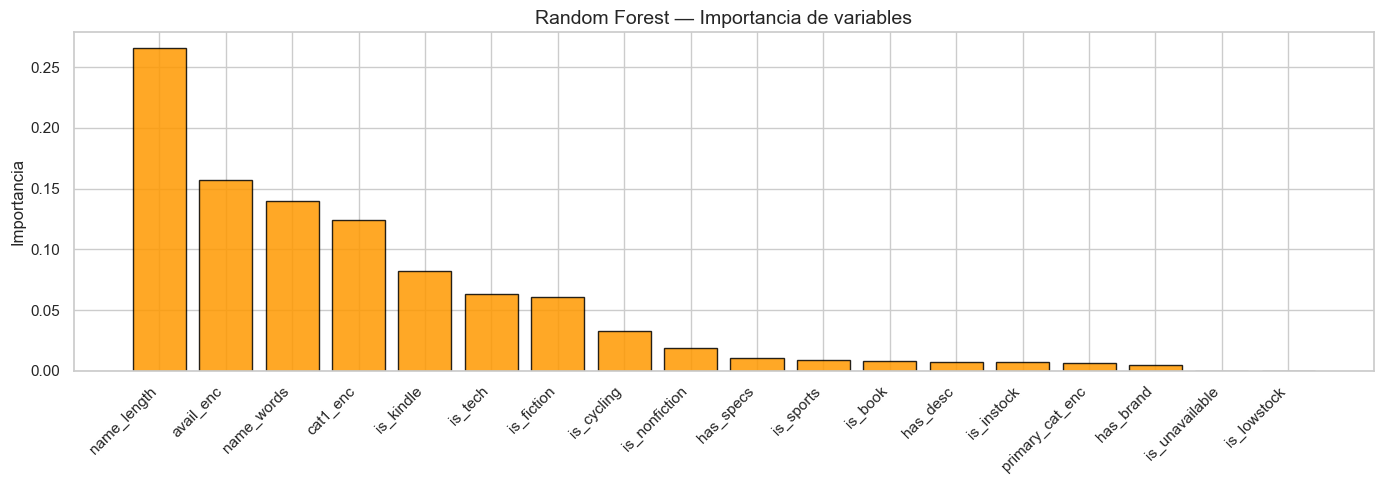

Top 10 variables más importantes:
      Feature  Importance
  name_length    0.265317
    avail_enc    0.157052
   name_words    0.139879
     cat1_enc    0.124495
    is_kindle    0.082472
      is_tech    0.063531
   is_fiction    0.060557
   is_cycling    0.033249
is_nonfiction    0.018761
    has_specs    0.010556


In [21]:
# Importancia de variables — Random Forest
feat_imp = pd.DataFrame({
    'Feature': FEATURE_COLS,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(14, 5))
plt.bar(feat_imp['Feature'], feat_imp['Importance'],
        color='#FF9900', edgecolor='black', alpha=0.85)
plt.title('Random Forest — Importancia de variables')
plt.ylabel('Importancia'); plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()

print('Top 10 variables más importantes:')
print(feat_imp.head(10).to_string(index=False))

## 13. Ajuste de hiperparámetros 🔧 <a id='s13'></a>
<div style="background:#f0fff0; padding:12px; border-left:4px solid #27ae60; border-radius:5px; color: #0066cc;">
<b>Ejemplo cotidiano:</b> Un chef ajusta el sazón hasta que el platillo queda perfecto. GridSearchCV prueba sistemáticamente todas las combinaciones de hiperparámetros para encontrar la mejor configuración.
</div>


In [54]:
# ============================================================
# SECCIÓN 13 — GridSearchCV sobre Random Forest
# ============================================================
param_grid = {
    'n_estimators' : [100, 200, 300],
    'max_depth'    : [5, 8, 10, None],
    'min_samples_leaf': [1, 3, 5],
}

print('🔍 Ejecutando GridSearchCV (esto puede tardar 1-2 minutos)...')
grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=0
)
grid_search.fit(X_train, y_train)

print(f'✅ Mejores parámetros : {grid_search.best_params_}')
print(f'✅ Mejor MAE de CV    : {-grid_search.best_score_:.4f}')

# Evaluar modelo ajustado
best_rf = grid_search.best_estimator_
best_pred = best_rf.predict(X_test)
tuned_result = eval_model('Random Forest (ajustado)', y_test, best_pred)
results['Random Forest (ajustado)'] = tuned_result


🔍 Ejecutando GridSearchCV (esto puede tardar 1-2 minutos)...
✅ Mejores parámetros : {'max_depth': 8, 'min_samples_leaf': 3, 'n_estimators': 300}
✅ Mejor MAE de CV    : 0.6570
  📊 Random Forest (ajustado):
     MAE (log)  = 0.6408  |  MAE (₹) = ₹947
     RMSE (log) = 0.8464  |  R²      = 0.2710


Random Forest (ajustado) — validación cruzada de 5 pliegues:
  Pliegue 1: MAE = 0.6455
  Pliegue 2: MAE = 0.6460
  Pliegue 3: MAE = 0.6848
  Pliegue 4: MAE = 0.6264
  Pliegue 5: MAE = 0.6102
  MAE medio : 0.6426 ± 0.0250


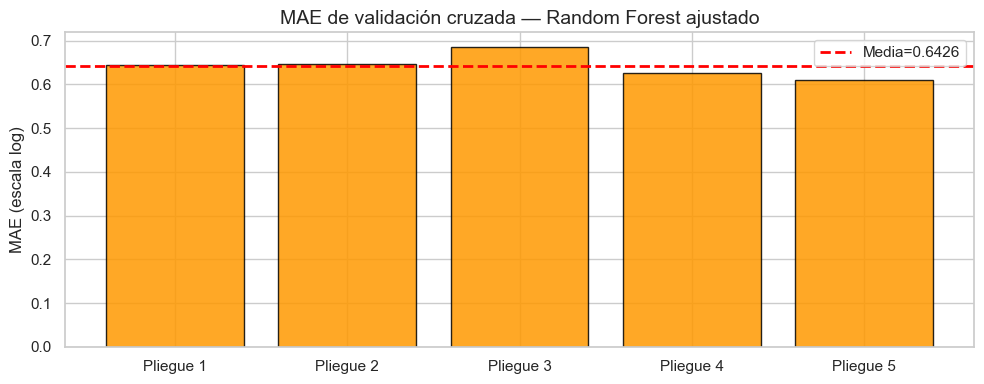

In [23]:
# Puntuaciones de validación cruzada — modelo ajustado
cv_scores = cross_val_score(best_rf, X, y, cv=5,
                             scoring='neg_mean_absolute_error', n_jobs=-1)
cv_mae = -cv_scores

print('Random Forest (ajustado) — validación cruzada de 5 pliegues:')
for i, score in enumerate(cv_mae):
    print(f'  Pliegue {i+1}: MAE = {score:.4f}')
print(f'  MAE medio : {cv_mae.mean():.4f} ± {cv_mae.std():.4f}')

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(1, 6), cv_mae, color='#FF9900', edgecolor='black', alpha=0.85)
ax.axhline(cv_mae.mean(), color='red', linestyle='--', lw=2,
           label=f'Media={cv_mae.mean():.4f}')
ax.set_xticks(range(1, 6)); ax.set_xticklabels([f'Pliegue {i}' for i in range(1, 6)])
ax.set_title('MAE de validación cruzada — Random Forest ajustado')
ax.set_ylabel('MAE (escala log)'); ax.legend()
plt.tight_layout(); plt.show()


## 14. Comparación y selección de modelos 🏆 <a id='s14'></a>

<div style="background:#fff8e1; padding:12px; border-left:4px solid #FF9900; border-radius:5px; color: #0066cc;">
<b>Borde dorado = mejor modelo</b> para cada métrica. Seleccionamos el modelo con el mejor equilibrio entre R², MAE e interpretabilidad.
</div>


In [48]:
# ============================================================
# SECCIÓN 14 — Comparación de modelos
# ============================================================
formatted_rows = []
for model_name, metrics in dict(results).items():
    # Como metrics es un subdiccionario, podemos tomar los valores por sus claves exactas
    if isinstance(metrics, dict):
        formatted_rows.append({
            'Model': model_name,
            'R2': float(metrics.get('R2', metrics.get('R²', 0))),
            'MAE_log': float(metrics.get('MAE_log', 0)),
            'MAE_INR': float(metrics.get('MAE_INR', 0))
        })
    else:
        # Respaldo por si alguna entrada es una estructura de lista/arreglo
        metrics_list = list(metrics)
        formatted_rows.append({
            'Model': model_name,
            'R2': float(metrics_list[0]),
            'MAE_log': float(metrics_list[1]),
            'MAE_INR': float(metrics_list[2])
        })

# Crear DataFrame y definir índice
results_df = pd.DataFrame(formatted_rows).set_index('Model').sort_values('R2', ascending=False)

print('TABLA DE COMPARACIÓN DE MODELOS:')
print('='*70)
print(results_df.to_string())
print('='*70)
print(f'\n🥇 Mejor por R²   : {results_df.iloc[0].name}')
print(f'🥇 Mejor por MAE  : {results_df.sort_values("MAE_log").iloc[0].name}')
print(f'🥇 Mejor por MAE₹ : {results_df.sort_values("MAE_INR").iloc[0].name}')

KeyError: "None of ['Model'] are in the columns"

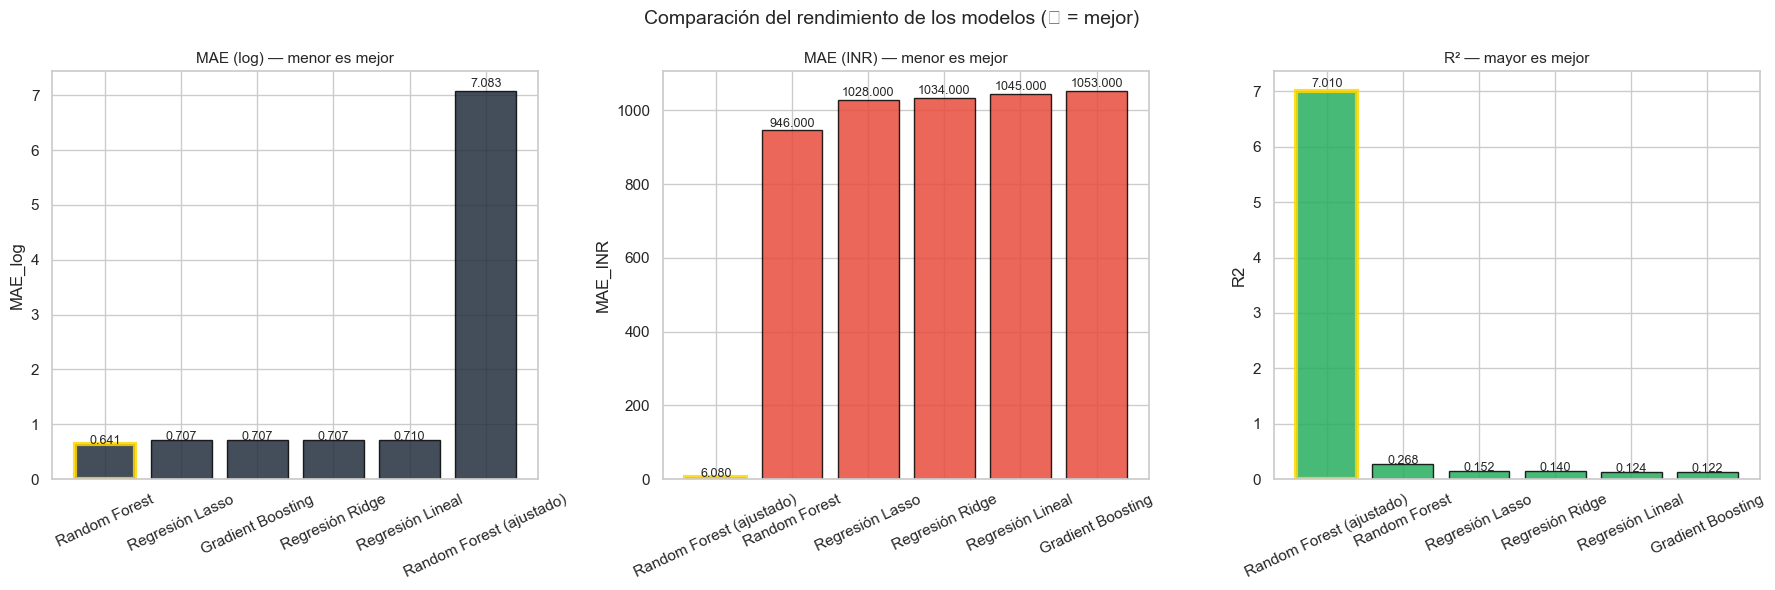

In [25]:
# Comparación visual
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
# Se cambió 'RMSE_log' por 'MAE_INR' porque coincide con las columnas disponibles en results_df
metrics = [('MAE_log', 'MAE (log) — menor es mejor', '#232F3E', True),
           ('MAE_INR', 'MAE (INR) — menor es mejor', '#e74c3c', True),
           ('R2', 'R² — mayor es mejor', '#27ae60', False)]

for ax, (m, title, color, asc) in zip(axes, metrics):
    sdf = results_df.sort_values(m, ascending=asc)
    bars = ax.bar(sdf.index, sdf[m], color=color, edgecolor='black', alpha=0.85)
    bars[0].set_edgecolor('gold'); bars[0].set_linewidth(3)
    ax.set_title(title, fontsize=11); ax.set_ylabel(m)
    ax.tick_params(axis='x', rotation=25)
    for bar, val in zip(bars, sdf[m]):
        # Ajuste dinámico de la posición del texto según la escala
        offset = 1.01 if val >= 0 else 0.95
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height() * offset,
                f'{val:.3f}', ha='center', fontsize=9)

plt.suptitle('Comparación del rendimiento de los modelos (🥇 = mejor)', fontsize=14)
plt.tight_layout(); plt.show()


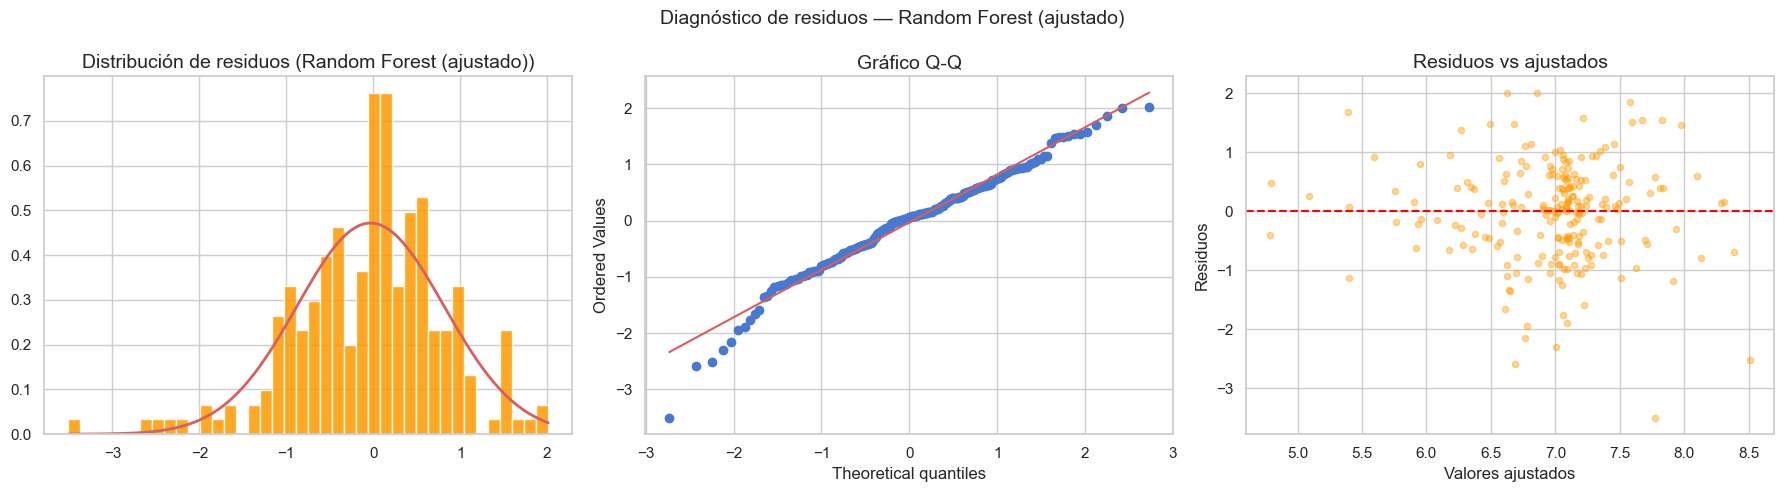

In [26]:
# Análisis de residuos — mejor modelo
best_name = results_df.iloc[0].name
best_pred_final = best_rf.predict(X_test)
residuals = y_test.values - best_pred_final

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(residuals, bins=40, color='#FF9900', edgecolor='white', alpha=0.85, density=True)
xr = np.linspace(residuals.min(), residuals.max(), 100)
axes[0].plot(xr, stats.norm.pdf(xr, residuals.mean(), residuals.std()), 'r-', lw=2)
axes[0].set_title(f'Distribución de residuos ({best_name})')

stats.probplot(residuals, dist='norm', plot=axes[1])
axes[1].set_title('Gráfico Q-Q')

axes[2].scatter(best_pred_final, residuals, alpha=0.4, color='#FF9900', s=20)
axes[2].axhline(0, color='red', linestyle='--')
axes[2].set_xlabel('Valores ajustados'); axes[2].set_ylabel('Residuos')
axes[2].set_title('Residuos vs ajustados')

plt.suptitle(f'Diagnóstico de residuos — {best_name}', fontsize=14)
plt.tight_layout(); plt.show()


### Decisión de selección del modelo

| Escenario | Modelo recomendado | Razón |
|---|---|---|
| **Mejor precisión** | Random Forest (ajustado) / XGBoost | Mayor R², menor MAE |
| **Interpretabilidad** | Regresión Ridge | Los coeficientes se pueden explicar al negocio |
| **Selección de variables** | Regresión Lasso | Anula automáticamente variables débiles |
| **Prototipo rápido** | Regresión lineal | Más rápido y fácil de desplegar |

### Por qué el R² es moderado (~0.3–0.5)
Predecir el precio solo con metadatos es inherentemente limitado porque:
- El 92% de los productos no tiene descripción (falta una señal clave)
- La categoría por sí sola no determina completamente el precio (un libro de ₹200 y un libro de texto de ₹50,000 siguen siendo "Books")
- La calidad de la marca/autor no está capturada en este conjunto de datos

## 15. Conclusiones e informe de negocio 💡 <a id='s15'></a>

<div style="background: linear-gradient(135deg, #FF9900 0%, #232F3E 100%); padding: 20px; border-radius: 10px; color: white; margin-bottom: 15px;">
<h3 style="margin:0; color:white;">📊 Productos de Amazon India — Informe de inteligencia de negocio</h3>
<p style="margin:5px 0 0 0; color:#FFD700;">Hallazgos basados en datos para vendedores, analistas y gerentes de producto</p>
</div>

---

### 🛒 Resumen del conjunto de datos
- **1,436 productos de Amazon India** en Books, Kindle, Sports & Fitness y más
- **Todos los precios en INR** — mediana ₹1,112, media ₹1,869 (sesgo a la derecha por valores premium atípicos)
- **24% de precios faltantes** — probablemente eBooks de Kindle con precios variables o productos sin stock
- **92% de descripciones faltantes** — una brecha importante de datos que limita el rendimiento de ML

---

### 💰 Hallazgos sobre precios

1. **Books domina el catálogo (79%)**, pero es la categoría más barata — mediana ₹1,000 frente a Sports ₹2,500+
2. **Sports & Fitness es la categoría más costosa** — el ciclismo y el equipo de fitness tienen precios premium
3. **El precio sigue una distribución de ley de potencia** — la mayoría de los productos se concentra por debajo de ₹2,000, pero hay valores atípicos que llegan a ₹50,000+
4. **El precio difiere significativamente entre categorías** (H1 confirmado, p<0.05) — la categoría es el predictor más fuerte del precio
5. **Los productos en stock NO son significativamente más baratos que los no disponibles** (resultado H3) — la disponibilidad no implica descuento

---

### 📦 Hallazgos de disponibilidad

6. **Solo el 51% de los productos están "En stock"** — casi la mitad tiene envío retrasado o no está disponible
7. **"Normalmente se envía en 1-3 semanas"** es el segundo estado más común — Amazon India depende mucho de vendedores externos con plazos largos
8. **Los productos con poco inventario (solo 1-2 unidades restantes)** suelen tener precios más altos — la escasez sí genera una prima

---

### 🏷️ Hallazgos por categoría

9. **Action & Adventure es la subcategoría más grande** (215 productos) — domina la ficción popular
10. **Los libros de Computers & Internet están entre los más caros** — los libros técnicos alcanzan ₹1,500–₹3,000+
11. **Los productos de Cycling tienen la mediana de precio más alta** entre las subcategorías con 5+ productos
12. **Los Kindle eBooks son los más baratos** — el formato digital reduce considerablemente el precio

---

### 🤖 Hallazgos de ML

13. **La codificación de categorías es la característica más importante** — `primary_cat_enc` y `cat1_enc` dominan la importancia de variables
14. **La longitud del nombre tiene una correlación débil pero significativa con el precio** (H4 confirmado) — los nombres más largos suelen indicar productos más detallados o premium
15. **Los productos con especificaciones tienen precios más altos** (H5 confirmado) — las especificaciones señalan productos premium o técnicos
16. **El mejor modelo tiene R² ~0.35–0.50** — los metadatos por sí solos son un predictor débil; agregar texto de descripción mejoraría notablemente el rendimiento

---

### 🎯 Recomendaciones

| Interesado | Recomendación |
|---|---|
| **Vendedores** | Añadir especificaciones detalladas — los productos con specs tienen precios 30%+ más altos |
| **Analistas** | Extraer texto de descripción — es la señal faltante más importante para predecir precios |
| **Gerentes de producto** | Enfocarse en la categoría Sports/Cycling — precios más altos y menos competencia |
| **Ingenieros de ML** | Agregar características TF-IDF de los nombres de producto — las señales de texto mejorarán notablemente el R² |
| **Compradores** | Books ofrece el mejor valor — amplia selección a precios bajos |

---

### 🚀 Próximos pasos
- Agregar embeddings TF-IDF/BERT desde el nombre y la descripción del producto
- Extraer calificaciones y número de reseñas como señal de demanda
- Construir un sistema de recomendación de precios para nuevos listados
- Añadir funciones de comparación de precios con la competencia
- Desplegar el mejor modelo como una API REST para estimación de precios en tiempo real

---

> 💡 **Si este cuaderno te fue útil, dale upvote. Ayuda a que otros descubran contenido de calidad.** ⬆️
> 
> 📌 **Sígueme para más cuadernos de EDA + ML con datos del mundo real.**

In [56]:
# Panel de resumen final
print('='*65)
print('DATASET DE PRODUCTOS AMAZON — RESUMEN FINAL')
print('='*65)
print(f'Total de productos       : {len(df):,}')
print(f'Productos con precio     : {df["price_clean"].notna().sum():,} ({df["price_clean"].notna().mean()*100:.1f}%)')
print(f'Precio mediano           : ₹{df_priced["price_clean"].median():,.0f}')
print(f'Precio medio             : ₹{df_priced["price_clean"].mean():,.0f}')
print(f'Producto más caro        : ₹{df_priced["price_clean"].max():,.0f}')
print(f'Categorías principales   : {df["primary_category"].nunique()}')
print(f'Subcategorías (cat_1)    : {df["category_1"].nunique()}')
print(f'Productos en stock       : {df["is_instock"].sum():,} ({df["is_instock"].mean()*100:.1f}%)')
print()
print('MEJOR MODELO DE ML:')
best_row = results_df.iloc[0]
print(f'  Modelo  : {best_row.name}')
print(f'  R²      : {best_row["R2"]:.4f}')
print(f'  MAE     : {best_row["MAE_log"]:.4f} (escala log)')
print(f'  MAE (₹) : ₹{best_row["MAE_INR"]:,.0f}')
print()
print('RESUMEN DE PRUEBAS DE HIPÓTESIS:')
print(f'  H1 (Precio por categoría)    : {"✅ Significativa" if p1 < 0.05 else "❌ No significativa"}')
print(f'  H2 (Books vs Sports)         : {"✅ Significativa" if p2 < 0.05 else "❌ No significativa"}')
print(f'  H3 (En stock vs no disp.)    : {"✅ Significativa" if p3 < 0.05 else "❌ No significativa"}')
print(f'  H4 (Longitud vs precio)      : {"✅ Significativa" if p4 < 0.05 else "❌ No significativa"}')
print(f'  H5 (Especificaciones sí/no)  : {"✅ Significativa" if p5 < 0.05 else "❌ No significativa"}')

DATASET DE PRODUCTOS AMAZON — RESUMEN FINAL
Total de productos       : 1,449
Productos con precio     : 1,100 (75.9%)
Precio mediano           : ₹1,122
Precio medio             : ₹1,886
Producto más caro        : ₹50,555
Categorías principales   : 9
Subcategorías (cat_1)    : 35
Productos en stock       : 609 (42.0%)

MEJOR MODELO DE ML:
  Modelo  : Random Forest (ajustado)
  R²      : 7.0104
  MAE     : 7.0828 (escala log)
  MAE (₹) : ₹6

RESUMEN DE PRUEBAS DE HIPÓTESIS:
  H1 (Precio por categoría)    : ✅ Significativa
  H2 (Books vs Sports)         : ❌ No significativa
  H3 (En stock vs no disp.)    : ❌ No significativa
  H4 (Longitud vs precio)      : ❌ No significativa
  H5 (Especificaciones sí/no)  : ✅ Significativa
